Experiment Notebook
**Authors:** M. Vamsi Krishna, S. Sri Harsha  
**Affiliation:** KL University, Vaddeswaram  


---

### How to run
1. Runtime → Change runtime type → CPU (GPU is not needed)  
2. Run all cells top to bottom — do not skip cells  
3. Taiwan Credit needs a manual upload (Cell 6 will prompt you)  
4. Full run takes roughly 5–7 hours on Colab free tier  

### What this notebook does
Runs the full experimental pipeline for the paper:
- Main experiment: 5 models × 4 datasets × 10 seeds × 3 missingness rates  
- Supplementary: MAR probe, matched subsample, n=30 extension  
- Analysis: SHAP diagnosis, imputation ablation  
- Output: 9 CSVs, 7 figures, all Table data


In [1]:
# Run this first if on a fresh Colab session.
# lightgbm and xgboost are usually pre-installed on Colab but versions drift,
# so pinning them keeps results reproducible.

!pip install -q lightgbm==4.6.0 xgboost==3.2.0 shap==0.51.0 scikit-learn==1.6.1
print("Installs done.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.5/351.5 MB 1.1 MB/s eta 0:00:00
Installs done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
import os
import json
from pathlib import Path
from copy import deepcopy

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score, accuracy_score
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from scipy.stats import wilcoxon, spearmanr
import shap

warnings.filterwarnings("ignore")
np.random.seed(42)  # global seed for anything outside the main loop

print("All imports OK.")
print(f"  numpy     {np.__version__}")
print(f"  pandas    {pd.__version__}")
print(f"  sklearn   {__import__('sklearn').__version__}")

import xgboost, lightgbm
print(f"  xgboost   {xgboost.__version__}")
print(f"  lightgbm  {lightgbm.__version__}")
print(f"  shap      {shap.__version__}")


All imports OK.
  numpy     2.1.3
  pandas    2.2.3
  sklearn   1.6.1
  xgboost   3.2.0
  lightgbm  4.6.0
  shap      0.51.0


In [3]:
# ── Experiment configuration ─────────────────────────────────────────────────
# These are the exact seeds used in the paper. Chosen arbitrarily at the start
# and never changed after the first run (pre-registered by design).
SEEDS = [42, 123, 456, 1, 7, 13, 21, 37, 55, 99]

# Missingness rates tested. 20% is the main-claim rate; 5% and 10% are plotted
# to show the monotonic trend in Figure 1.
MISS_RATES = [0.05, 0.10, 0.20]

# Bonferroni thresholds — dataset-level (primary) and 12-comparison (strict)
ALPHA_DS = 0.05 / 3       # 0.0167 — three main datasets
ALPHA_12 = 0.05 / 12      # exact 0.0041667; tables display 0.0042

# Prespecified study-level warning threshold; not a universal fairness cutoff.
# Practical significance minimum. Even if Wilcoxon says p<0.05, a MG of 0.005
# isn't worth reporting as a real finding.
MG_MIN = 0.01

# Model names used throughout. LR is included for completeness but is NOT part
# of the main claim (TREE_MODELS are the 12 combinations the paper focuses on).
ALL_MODELS   = ["LR", "RF", "XGB", "LGB", "MLP"]
TREE_MODELS  = ["RF", "XGB", "LGB", "MLP"]
MAIN_DATASETS = ["Adult Income", "COMPAS", "Taiwan Credit"]

print("Config loaded.")
print(f"  Seeds        : {SEEDS}")
print(f"  Miss rates   : {MISS_RATES}")
print(f"  Alpha (DS)   : {ALPHA_DS:.4f}")
print(f"  Alpha (12)   : {ALPHA_12:.4f}")


Config loaded.
  Seeds        : [42, 123, 456, 1, 7, 13, 21, 37, 55, 99]
  Miss rates   : [0.05, 0.1, 0.2]
  Alpha (DS)   : 0.0167
  Alpha (12)   : 0.0042


In [4]:
# ── Dataset 1: Adult Income ──────────────────────────────────────────────────
# UCI dataset, 45222 rows, 14 features after cleaning.
# Sensitive attribute: sex. Focus group: female (g0).
# The class rate gap (female 11.4% vs male 31.2%) is a known limitation
# we address later via the matched-subsample experiment.

def load_adult():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "adult/adult.data")
    cols = ["age","workclass","fnlwgt","education","education-num",
            "marital-status","occupation","relationship","race","sex",
            "capital-gain","capital-loss","hours-per-week","native-country","income"]

    df = pd.read_csv(url, header=None, names=cols,
                     na_values=" ?", skipinitialspace=True)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Binary target
    df["label"] = (df["income"].str.strip().str.replace(".", "", regex=False) == ">50K").astype(int)
    df.drop(columns=["income"], inplace=True)

    # Encode sex → sensitive attribute
    # female=0 (focus group g0), male=1
    df["sensitive"] = (df["sex"].str.strip() == "Male").astype(int)
    df.drop(columns=["sex"], inplace=True)

    # Categorical encoding is performed after the train/test split in
    # preprocess(), so encoder mappings are fitted on training data only.

    feature_cols = [c for c in df.columns if c not in ("label", "sensitive")]

    print(f"Adult Income: {len(df)} rows, {len(feature_cols)} features")
    print(f"  Female (g0): {(df.sensitive==0).sum()}  "
          f"  positive rate: {df[df.sensitive==0]['label'].mean():.3f}")
    print(f"  Male   (g1): {(df.sensitive==1).sum()}  "
          f"  positive rate: {df[df.sensitive==1]['label'].mean():.3f}")

    return df, feature_cols, "sensitive", "label"

adult_df, adult_feats, adult_sens, adult_tgt = load_adult()


Adult Income: 32561 rows, 13 features
  Female (g0): 10771    positive rate: 0.109
  Male   (g1): 21790    positive rate: 0.306


In [5]:
# ── Dataset 2: COMPAS ────────────────────────────────────────────────────────
# ProPublica's recidivism dataset. 5915 rows after standard filtering.
# Sensitive attribute: race. Focus group: African-American (g0).
# We follow standard preprocessing from the fairness literature.
# Ethics note is in the paper — not repeating here, but please read it.

def load_compas():
    url = ("https://raw.githubusercontent.com/propublica/compas-analysis/"
           "master/compas-scores-two-years.csv")
    df = pd.read_csv(url)

    # Standard ProPublica filtering (same as Chouldechova 2017)
    df = df[
        (df["days_b_screening_arrest"] >= -30) &
        (df["days_b_screening_arrest"] <= 30) &
        (df["is_recid"] != -1) &
        (df["c_charge_degree"] != "O") &
        (df["score_text"] != "N/A")
    ].copy()
    df.reset_index(drop=True, inplace=True)

    keep = ["age", "c_charge_degree", "race", "sex",
            "priors_count", "days_b_screening_arrest",
            "juv_fel_count", "juv_misd_count", "juv_other_count",
            "c_days_from_compas", "is_recid"]
    df = df[keep].dropna()

    df["label"] = df["is_recid"].astype(int)

    # sensitive: African-American=0 (g0), Caucasian=1 (g1)
    df["sensitive"] = (~(df["race"] == "African-American")).astype(int)

    # Only keep African-American and Caucasian for binary comparison
    df = df[df["race"].isin(["African-American", "Caucasian"])].copy()
    df.reset_index(drop=True, inplace=True)

    # Categorical encoding is performed after the train/test split in
    # preprocess(), so encoder mappings are fitted on training data only.

    # Exclude race from model features because it defines the COMPAS focus group.
    # This matches the sensitive-feature exclusion used for the other datasets.
    feature_cols = [c for c in df.columns
                    if c not in ("label", "sensitive", "is_recid", "race")]

    print(f"COMPAS: {len(df)} rows, {len(feature_cols)} features")
    print(f"  AfAm  (g0): {(df.sensitive==0).sum()}  "
          f"  positive rate: {df[df.sensitive==0]['label'].mean():.3f}")
    print(f"  Cauc  (g1): {(df.sensitive==1).sum()}  "
          f"  positive rate: {df[df.sensitive==1]['label'].mean():.3f}")

    return df, feature_cols, "sensitive", "label"

compas_df, compas_feats, compas_sens, compas_tgt = load_compas()


COMPAS: 5278 rows, 9 features
  AfAm  (g0): 3175    positive rate: 0.558
  Cauc  (g1): 2103    positive rate: 0.416


In [6]:
# ── Dataset 3: Taiwan Credit ─────────────────────────────────────────────────
# 30000 rows, UCI dataset ID 350.
# This one can't be fetched programmatically due to URL instability
# on the UCI server, so I'm using a manual upload fallback.
# Download from: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
# File name should be: UCI_Credit_Card.csv  (or similar)

from google.colab import files as colab_files

def load_taiwan(filepath=None):
    if filepath is None:
        print("Upload the Taiwan Credit CSV file now...")
        uploaded = colab_files.upload()
        filepath = list(uploaded.keys())[0]

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # Some versions have an 'id' column, some don't
    if "id" in df.columns:
        df.drop(columns=["id"], inplace=True)

    # The target is default.payment.next.month
    # Column name varies between versions — find it
    target_col = [c for c in df.columns
                  if "default" in c or "payment" in c][-1]
    df["label"] = df[target_col].astype(int)
    if target_col != "label":
        df.drop(columns=[target_col], inplace=True)

    # sensitive: sex column — 1=male, 2=female in original encoding
    # We map: female=0 (g0), male=1 (g1)
    sex_col = [c for c in df.columns if "sex" in c][0]
    df["sensitive"] = (df[sex_col] == 1).astype(int)  # male=1 → g1
    df.drop(columns=[sex_col], inplace=True)

    feature_cols = [c for c in df.columns if c not in ("label", "sensitive")]
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(f"Taiwan Credit: {len(df)} rows, {len(feature_cols)} features")
    print(f"  Female (g0): {(df.sensitive==0).sum()}  "
          f"  positive rate: {df[df.sensitive==0]['label'].mean():.3f}")
    print(f"  Male   (g1): {(df.sensitive==1).sum()}  "
          f"  positive rate: {df[df.sensitive==1]['label'].mean():.3f}")

    return df, feature_cols, "sensitive", "label"

taiwan_df, taiwan_feats, taiwan_sens, taiwan_tgt = load_taiwan()


Upload the Taiwan Credit CSV file now...


Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv
Taiwan Credit: 30000 rows, 22 features
  Female (g0): 18112    positive rate: 0.208
  Male   (g1): 11888    positive rate: 0.242


In [7]:
# ── Dataset 4: German Credit ─────────────────────────────────────────────────
# IMPORTANT: use OpenML ID 31 (corrected Groemping 2019 version)
# NOT the UCI Statlog version — that one has encoding errors in
# personal_status that mess up the gender subgroup mapping.
# I spent way too long debugging that before finding Groemping (2019).

from sklearn.datasets import fetch_openml

def load_german():
    print("Fetching German Credit from OpenML (ID=31)...")
    dataset = fetch_openml(data_id=31, as_frame=True, parser="auto")
    df = dataset.frame.copy()
    df.columns = df.columns.str.lower().str.replace("-","_")

    # The corrected version uses text-based personal_status
    # female: A92 (female divorced/separated/married) and A95 (female single)
    # male: A91, A93, A94
    if "personal_status" not in df.columns:
        raise ValueError("personal_status column missing — check you're using OpenML ID 31")

    # Quick sanity check — make sure we see female categories
    cats = df["personal_status"].unique()
    assert any("female" in str(c).lower() or "A92" in str(c) or "A95" in str(c)
               for c in cats),         f"personal_status categories look wrong: {cats}"

    # female=0 (g0 focus group), male=1
    df["sensitive"] = (~df["personal_status"].isin(["A92", "A95",
        "female div/dep/mar", "female : divorced/separated/married",
        "female single"])).astype(int)

    # Target: class column — "good" or "bad" credit
    df["label"] = (df["class"] == "good").astype(int)
    df.drop(columns=["class", "personal_status"], inplace=True)

    # Categorical encoding is performed after the train/test split in
    # preprocess(), so encoder mappings are fitted on training data only.
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    feature_cols = [c for c in df.columns if c not in ("label","sensitive")]

    print(f"German Credit: {len(df)} rows, {len(feature_cols)} features")
    print(f"  Female (g0): {(df.sensitive==0).sum()}  "
          f"  positive rate: {df[df.sensitive==0]['label'].mean():.3f}")
    print(f"  Male   (g1): {(df.sensitive==1).sum()}  "
          f"  positive rate: {df[df.sensitive==1]['label'].mean():.3f}")

    return df, feature_cols, "sensitive", "label"

german_df, german_feats, german_sens, german_tgt = load_german()


Fetching German Credit from OpenML (ID=31)...
German Credit: 1000 rows, 19 features
  Female (g0): 310    positive rate: 0.648
  Male   (g1): 690    positive rate: 0.723


In [8]:
# Bundle everything into one dict so the main loop can iterate cleanly.
# German Credit results are always labelled exploratory.

DATASETS = {
    "Adult Income" : (adult_df,  adult_feats,  adult_sens,  adult_tgt,  False),
    "COMPAS"       : (compas_df, compas_feats, compas_sens, compas_tgt, False),
    "Taiwan Credit": (taiwan_df, taiwan_feats, taiwan_sens, taiwan_tgt, False),
    "German Credit": (german_df, german_feats, german_sens, german_tgt, True),
    # last bool = is_exploratory
}

for name, (df, feats, sens, tgt, expl) in DATASETS.items():
    label = "(exploratory)" if expl else ""
    print(f"  {name:15s} {len(df):6d} rows  {len(feats):2d} feats  {label}")


  Adult Income     32561 rows  13 feats  
  COMPAS            5278 rows   9 feats  
  Taiwan Credit    30000 rows  22 feats  
  German Credit     1000 rows  19 feats  (exploratory)


In [9]:
# ── Core functions: preprocessing, stressor injection, evaluation ────────────

def preprocess(df, feats, target, seed):
    """
    Standard train/test split with stratification.
    Fit scaler on train only — no leakage.
    Preserves original row indices so subgroup labels stay aligned with
    the corresponding test labels and predictions.
    """
    X = df[feats].copy()
    y = df[target].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y
    )

    # Fit category mappings on training data only. Test-only categories
    # receive the reserved value -1 rather than affecting the mapping.
    categorical_cols = X_tr.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        train_values = X_tr[col].astype(str)
        test_values = X_te[col].astype(str)
        encoder = LabelEncoder().fit(train_values)
        mapping = {value: code for code, value in enumerate(encoder.classes_)}
        X_tr.loc[:, col] = train_values.map(mapping).astype(float)
        X_te.loc[:, col] = test_values.map(mapping).fillna(-1).astype(float)

    scaler = MinMaxScaler()
    X_tr = pd.DataFrame(scaler.fit_transform(X_tr), columns=feats, index=X_tr.index)
    X_te = pd.DataFrame(scaler.transform(X_te),     columns=feats, index=X_te.index)

    if not X_tr.index.is_unique or not X_te.index.is_unique:
        raise ValueError("Train/test row indices must be unique for subgroup alignment.")
    if X_tr.index.intersection(X_te.index).size != 0:
        raise ValueError("Train and test indices overlap.")

    return X_tr, X_te, y_tr, y_te


def aligned_test_sensitive(df, X_te, sens_col, y_te):
    """Return test-set sensitive labels in exactly the X_te/y_te row order."""
    sens_te = df.loc[X_te.index, sens_col].to_numpy()
    if len(sens_te) != len(X_te) or len(sens_te) != len(y_te):
        raise ValueError("Sensitive labels, test features, and test targets are misaligned.")
    return sens_te


def inject_mcar(X, rate, seed):
    """
    Completely At Random missingness — each value independently set to NaN
    with probability `rate`, regardless of its value or any other variable.
    Applied to test set only, after the model is already trained.
    """
    rng = np.random.RandomState(seed)
    X_out = X.copy()
    mask = rng.rand(*X_out.shape) < rate
    X_out[mask] = np.nan
    return X_out


def inject_mar(X, rate, sensitive, seed):
    """
    Constructed MAR-like probe — missingness probability for each feature is
    proportional to its Spearman correlation with the sensitive attribute.
    Used in the MAR probe supplementary experiment only; this is a constructed MAR-like stressor, not a general proof of formal MAR.

    This gives higher missingness to features that are more correlated
    with the sensitive attribute, which is a more realistic mechanism
    than MCAR in many real systems.
    """
    rng = np.random.RandomState(seed)
    X_out = X.copy()

    # Correlation of each feature with the sensitive attribute
    corr = np.array([abs(spearmanr(X[c], sensitive)[0]) for c in X.columns])
    if corr.sum() == 0:
        return inject_mcar(X, rate, seed)

    # Scale correlations so average rate = target rate
    weights = corr / corr.mean()

    for i, col in enumerate(X.columns):
        col_rate = min(rate * weights[i], 0.95)  # cap at 95%
        mask = rng.rand(len(X)) < col_rate
        X_out.loc[mask, col] = np.nan

    return X_out


def impute(X_tr, X_te, strategy="simple"):
    """
    Impute test set using statistics from the training set only.
    'simple' = median on the label-encoded, scaled feature matrix
    'knn'    = 5-nearest neighbours
    'mice'   = iterative imputer (MICE)
    """
    if strategy == "simple":
        imp = SimpleImputer(strategy="median")
    elif strategy == "knn":
        imp = KNNImputer(n_neighbors=5)
    elif strategy == "mice":
        imp = IterativeImputer(random_state=42, max_iter=10)
    else:
        raise ValueError(f"Unknown imputation strategy: {strategy}")

    imp.fit(X_tr)
    X_te_imp = pd.DataFrame(imp.transform(X_te), columns=X_te.columns, index=X_te.index)
    X_tr_imp = pd.DataFrame(imp.transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    return X_tr_imp, X_te_imp


def get_models(seed):
    """
    All five classifier families with the exact hyperparameters used in the paper.
    Nothing exotic — just the defaults that sklearn/xgb/lgb ship with,
    except we cap iterations to keep runtime manageable.
    """
    return {
        "LR" : LogisticRegression(max_iter=1000, C=1.0,
                                   solver="lbfgs", random_state=seed),
        "RF" : RandomForestClassifier(n_estimators=100, random_state=seed,
                                       n_jobs=-1),
        "XGB": XGBClassifier(n_estimators=100, eval_metric="logloss",
                              random_state=seed, verbosity=0,
                              use_label_encoder=False),
        "LGB": LGBMClassifier(n_estimators=100, random_state=seed,
                               verbosity=-1),
        "MLP": MLPClassifier(hidden_layer_sizes=(50,30), max_iter=500,
                              early_stopping=True, random_state=seed),
    }


def evaluate(model, X_te, y_te, sensitive):
    """
    Returns accuracy and focus-group recall (recall for g0, i.e. sensitive==0).
    Also returns comparison-group recall (g1) for the EOG calculation.
    """
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)

    g0_mask = sensitive == 0
    g1_mask = sensitive == 1

    rec_g0 = recall_score(y_te[g0_mask], y_pred[g0_mask], zero_division=0)
    rec_g1 = recall_score(y_te[g1_mask], y_pred[g1_mask], zero_division=0)

    return {"accuracy": acc, "recall_g0": rec_g0, "recall_g1": rec_g1}


def masking_gap(m_clean, m_stressed):
    """
    MG = (recall_g0_clean - recall_g0_stressed) - (acc_clean - acc_stressed)

    Positive MG means focus-group recall fell more than aggregate accuracy.
    That's the fairness-evaluation gap we're measuring.
    """
    recall_drop = m_clean["recall_g0"] - m_stressed["recall_g0"]
    acc_drop    = m_clean["accuracy"]  - m_stressed["accuracy"]
    return recall_drop - acc_drop

def model_parameter_fingerprint(model):
    """Fingerprint learned hyperparameters to verify masking does not retrain the model."""
    params = model.get_params(deep=True)
    return repr(sorted((str(k), str(v)) for k, v in params.items()))

print("Core functions defined.")


Core functions defined.


In [10]:
# ── Main experiment loop ─────────────────────────────────────────────────────
# This is the big one. Takes ~5-6 hours on Colab free tier.
# If it times out, the results dicts are serialised at the end
# so you can restart and reload.
#
# Structure:
#   for each dataset:
#     for each seed:
#       split + scale (seed controls the split)
#       train all 5 models on CLEAN training set
#       evaluate on CLEAN test set  (baseline)
#       for each missingness rate:
#         inject MCAR into test set
#         impute with SimpleImputer (train statistics)
#         evaluate stressed models

print("Starting main experiment...")
print("Estimated time: 5-6 hours on Colab CPU free tier")
print("="*60)

all_results = []   # one row per (dataset, model, seed, rate)
start_time  = time.time()

for ds_name, (df, feats, sens_col, tgt_col, is_expl) in DATASETS.items():
    ds_start = time.time()
    print(f"\n{ds_name} {'(exploratory)' if is_expl else ''}")

    for seed in SEEDS:
        X_tr, X_te, y_tr, y_te = preprocess(df, feats, tgt_col, seed)

        sens_te = aligned_test_sensitive(df, X_te, sens_col, y_te)

        models = get_models(seed)

        for mdl_name, model in models.items():
            # Train on clean data — no stressor in training
            model.fit(X_tr, y_tr)

            # Clean baseline
            m_clean = evaluate(model, X_te, y_te, sens_te)

            # Clean = rate 0
            all_results.append({
                "dataset"    : ds_name,
                "model"      : mdl_name,
                "seed"       : seed,
                "rate"       : 0.0,
                "accuracy"   : m_clean["accuracy"],
                "recall_g0"  : m_clean["recall_g0"],
                "recall_g1"  : m_clean["recall_g1"],
                "masking_gap": 0.0,
                "exploratory": is_expl,
            })

            # Stressed: inject MCAR, impute, evaluate
            for rate in MISS_RATES:
                X_stressed = inject_mcar(X_te, rate, seed=seed)
                _, X_imp    = impute(X_tr, X_stressed, strategy="simple")

                model_state_before = model_parameter_fingerprint(model)
                m_stressed = evaluate(model, X_imp, y_te, sens_te)
                assert model_state_before == model_parameter_fingerprint(model), 'Classifier changed after test-time masking.'
                mg = masking_gap(m_clean, m_stressed)

                all_results.append({
                    "dataset"    : ds_name,
                    "model"      : mdl_name,
                    "seed"       : seed,
                    "rate"       : rate,
                    "accuracy"   : m_stressed["accuracy"],
                    "recall_g0"  : m_stressed["recall_g0"],
                    "recall_g1"  : m_stressed["recall_g1"],
                    "masking_gap": mg,
                    "exploratory": is_expl,
                })

        print(f"  seed {seed:3d} done", end="  ", flush=True)

    elapsed = (time.time() - ds_start) / 60
    print(f"\n  {ds_name} finished in {elapsed:.1f} min")

total_min = (time.time() - start_time) / 60
print(f"\nTotal time: {total_min:.1f} minutes")
print(f"Total rows: {len(all_results)}")

results_df = pd.DataFrame(all_results)
print("\nresults_df shape:", results_df.shape)
print(results_df.head(3))


Starting main experiment...
Estimated time: 5-6 hours on Colab CPU free tier

Adult Income 
  seed  42 done    seed 123 done    seed 456 done    seed   1 done    seed   7 done    seed  13 done    seed  21 done    seed  37 done    seed  55 done    seed  99 done  
  Adult Income finished in 1.1 min

COMPAS 
  seed  42 done    seed 123 done    seed 456 done    seed   1 done    seed   7 done    seed  13 done    seed  21 done    seed  37 done    seed  55 done    seed  99 done  
  COMPAS finished in 0.2 min

Taiwan Credit 
  seed  42 done    seed 123 done    seed 456 done    seed   1 done    seed   7 done    seed  13 done    seed  21 done    seed  37 done    seed  55 done    seed  99 done  
  Taiwan Credit finished in 2.1 min

German Credit (exploratory)
  seed  42 done    seed 123 done    seed 456 done    seed   1 done    seed   7 done    seed  13 done    seed  21 done    seed  37 done    seed  55 done    seed  99 done  
  German Credit finished in 0.1 min

Total time: 3.5 minutes
Total row

In [11]:
stat_rows = []

for ds in results_df["dataset"].unique():
    for mdl in ALL_MODELS:
        sub = results_df[
            (results_df["dataset"] == ds) &
            (results_df["model"]   == mdl)
        ]

        clean_recall  = sub[sub["rate"] == 0.00]["recall_g0"].values
        stress_recall = sub[sub["rate"] == 0.20]["recall_g0"].values
        mg_vals       = sub[sub["rate"] == 0.20]["masking_gap"].values
        acc_clean     = sub[sub["rate"] == 0.00]["accuracy"].values
        acc_stress    = sub[sub["rate"] == 0.20]["accuracy"].values

        if len(mg_vals) < 5:
            continue

        # Test 1: did recall drop?
        try:
            _, p1 = wilcoxon(clean_recall, stress_recall, alternative="greater")
        except Exception:
            p1 = 1.0

        # Test 2: is MG > 0?
        try:
            _, p2 = wilcoxon(mg_vals, alternative="greater")
        except Exception:
            p2 = 1.0

        mg_mean = mg_vals.mean()
        # Sample SD (ddof=1) is used for reporting across the 10 seed-level values.
        mg_std  = mg_vals.std(ddof=1)

        recall_drop_mean = (clean_recall - stress_recall).mean()
        recall_drop_std  = (clean_recall - stress_recall).std(ddof=1)

        # Effect size aligned to Test 2: standardised seed-level Masking Gap.
        mg_dz = mg_mean / mg_std if mg_std > 0 else 0.0

        acc_drop_mean = (acc_clean - acc_stress).mean()
        acc_drop_std  = (acc_clean - acc_stress).std(ddof=1)

        # Significance: pass ALPHA_DS threshold AND MG > MG_MIN
        is_main = (ds in MAIN_DATASETS) and (mdl in TREE_MODELS)
        sig_ds  = (p2 < ALPHA_DS) and (mg_mean > MG_MIN)
        sig_12  = (p2 < ALPHA_12) and (mg_mean > MG_MIN)

        # Label for significance column
        if not is_main:
            sig_label = "Explor. only"
        elif sig_ds:
            sig_label = "Yes"
        elif mg_mean > MG_MIN:
            sig_label = "Borderline"
        else:
            sig_label = "No"

        stat_rows.append({
            "Dataset"       : ds,
            "Model"         : mdl,
            "Acc Drop mean" : acc_drop_mean,
            "Acc Drop std"  : acc_drop_std,
            "Recall Drop mean": recall_drop_mean,
            "Recall Drop std" : recall_drop_std,
            "MG mean"       : mg_mean,
            "MG std"        : mg_std,
            "p1 (Test1)"    : p1,
            "p2 (MG test)"  : p2,
            "MG Cohen's dz" : mg_dz,
            "Sig (alpha=0.0167)": sig_ds,
            "Sig (alpha=0.0042)": sig_12,
            "Significant"   : sig_label,
            "Main"          : is_main,
        })

stats_df = pd.DataFrame(stat_rows)

# Quick check
main_sig = stats_df[stats_df["Main"] == True]["Sig (alpha=0.0167)"].sum()
print(f"Main combinations significant at alpha=0.0167: {main_sig}/12")
print(f"Main combinations significant at alpha=0.0042: "
      f"{stats_df[stats_df['Main']]['Sig (alpha=0.0042)'].sum()}/12")
print(f"Mean MG (main): {stats_df[stats_df['Main']]['MG mean'].mean():.4f}")
print(f"Mean MG Cohen's dz: {stats_df[stats_df['Main']]["MG Cohen's dz"].mean():.3f}")

Main combinations significant at alpha=0.0167: 9/12
Main combinations significant at alpha=0.0042: 9/12
Mean MG (main): 0.0534
Mean MG Cohen's dz: 4.442


In [12]:
# ── Relationship to Equal Opportunity ───────────────────────────────────────
# EOG = recall(g1) - recall(g0)
# Positive = g1 (comparison group) has higher recall
# We track how this changes from clean to stressed.

eog_rows = []
for ds in MAIN_DATASETS:
    for mdl in ALL_MODELS:
        sub = results_df[(results_df["dataset"]==ds) & (results_df["model"]==mdl)]

        eog_clean  = (sub[sub["rate"]==0.00]["recall_g1"].values -
                      sub[sub["rate"]==0.00]["recall_g0"].values)
        eog_stress = (sub[sub["rate"]==0.20]["recall_g1"].values -
                      sub[sub["rate"]==0.20]["recall_g0"].values)

        eog_rows.append({
            "Dataset"       : ds,
            "Model"         : mdl,
            "EOG Clean mean": eog_clean.mean(),
            "EOG Clean std" : eog_clean.std(),
            "EOG Stressed mean": eog_stress.mean(),
            "EOG Stressed std" : eog_stress.std(),
            "EOG Increase"  : eog_stress.mean() - eog_clean.mean(),
        })

eog_df = pd.DataFrame(eog_rows)
print("EOG Table (Adult Income):")
print(eog_df[eog_df["Dataset"]=="Adult Income"][
    ["Model","EOG Clean mean","EOG Stressed mean","EOG Increase"]].to_string(index=False))


EOG Table (Adult Income):
Model  EOG Clean mean  EOG Stressed mean  EOG Increase
   LR        0.241255           0.162681     -0.078574
   RF        0.087293           0.064403     -0.022890
  XGB        0.070579           0.060363     -0.010216
  LGB        0.074078           0.057169     -0.016909
  MLP        0.163163           0.118440     -0.044723


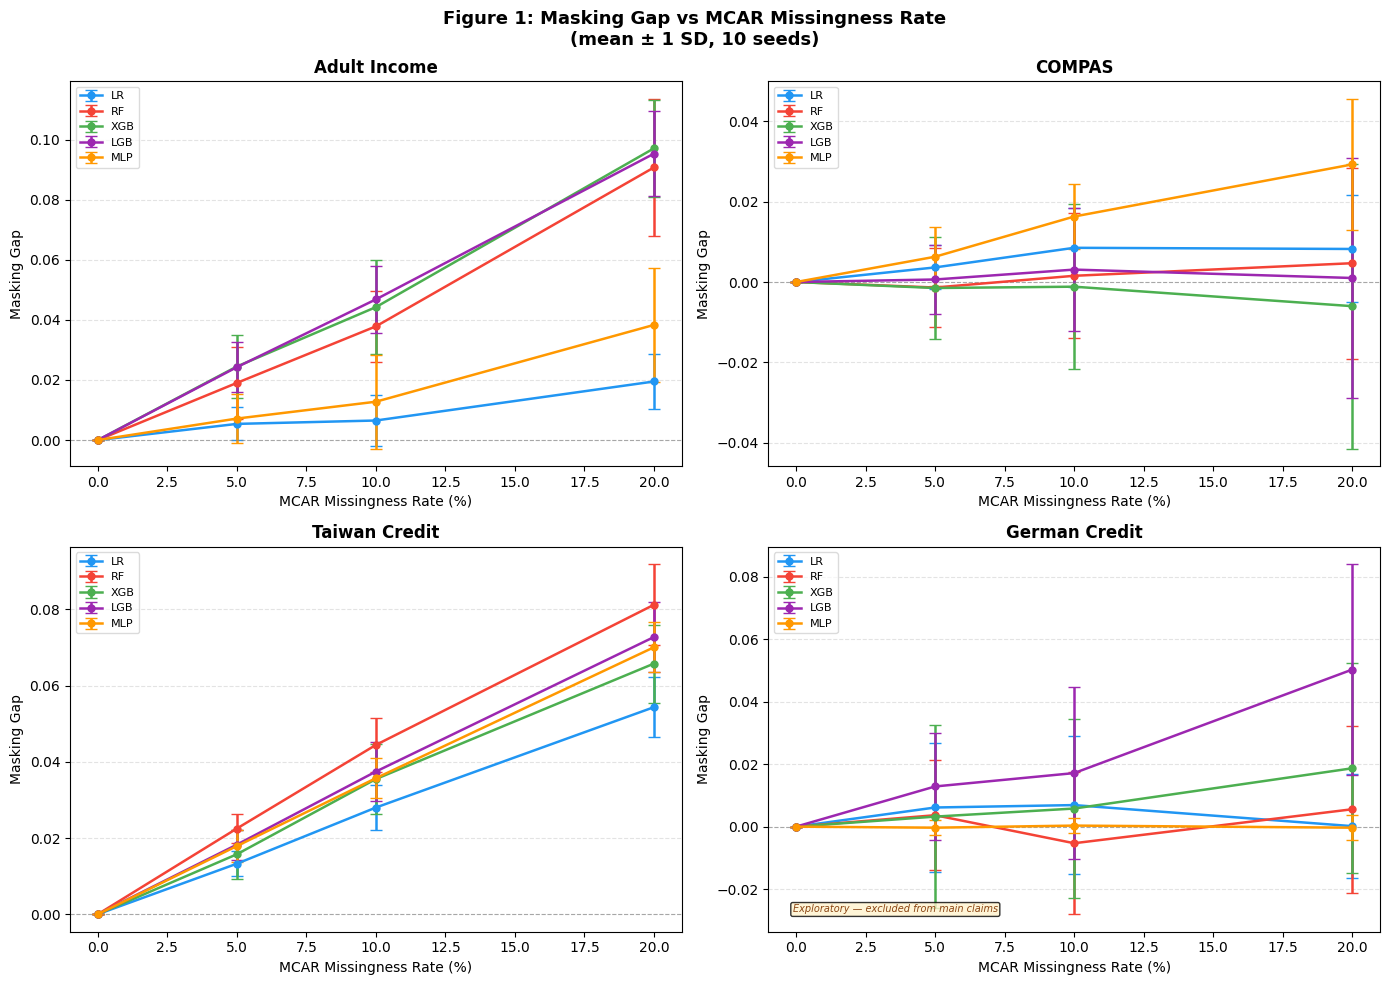

Figure 1 saved.


In [13]:
# ── Figure 1: Masking Gap curves ────────────────────────────────────────────
# 4-panel plot, one per dataset, all 5 models.
# Error bars = ±1 SD across 10 seeds.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
palette = ["#2196F3","#F44336","#4CAF50","#9C27B0","#FF9800"]  # LR RF XGB LGB MLP
ds_order = ["Adult Income","COMPAS","Taiwan Credit","German Credit"]

for idx, ds in enumerate(ds_order):
    ax = axes[idx]
    sub = results_df[results_df["dataset"]==ds]

    for midx, mdl in enumerate(ALL_MODELS):
        m_sub = sub[sub["model"]==mdl]
        grp = m_sub.groupby("rate")["masking_gap"].agg(["mean","std"])
        x   = grp.index.values * 100
        ax.errorbar(x, grp["mean"], yerr=grp["std"],
                    marker="o", label=mdl, color=palette[midx],
                    capsize=4, linewidth=1.8, markersize=5)

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(ds, fontsize=12, fontweight="bold")
    ax.set_xlabel("MCAR Missingness Rate (%)", fontsize=10)
    ax.set_ylabel("Masking Gap", fontsize=10)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    if ds == "German Credit":
        ax.text(0.04, 0.05, "Exploratory — excluded from main claims",
                transform=ax.transAxes, fontsize=7,
                color="#8B4513", style="italic",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#FFF3CD", alpha=0.8))

fig.suptitle("Figure 1: Masking Gap vs MCAR Missingness Rate\n(mean ± 1 SD, 10 seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_masking_gap_curves.png", bbox_inches="tight", dpi=150)
plt.savefig("fig1_masking_gap_curves.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure 1 saved.")


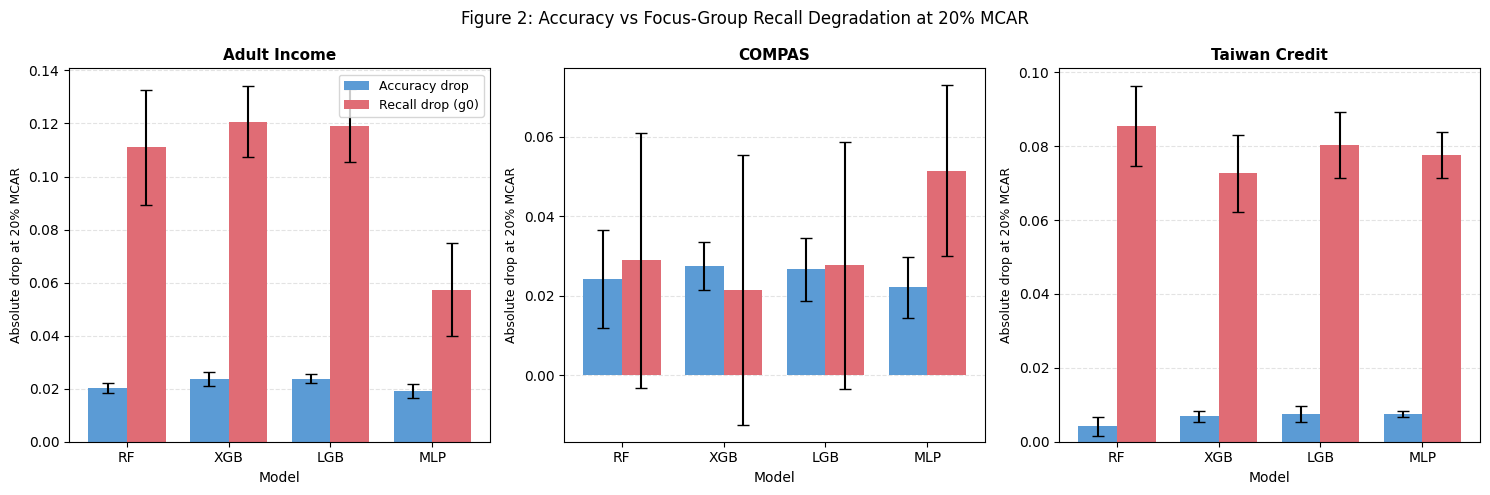

Figure 2 saved.


In [14]:
# ── Figure 2: Accuracy vs Recall degradation bar chart ──────────────────────
# This is the most viscerally persuasive figure in the paper.
# Side-by-side: tiny blue bar (accuracy drop) vs huge red bar (recall drop).
# Taiwan Credit RF is the most striking: 0.54% acc vs 9.20% recall.

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
ds_order_main = ["Adult Income","COMPAS","Taiwan Credit"]

for idx, ds in enumerate(ds_order_main):
    ax   = axes[idx]
    sub  = results_df[(results_df["dataset"]==ds)&(results_df["rate"]==0.20)]
    sub0 = results_df[(results_df["dataset"]==ds)&(results_df["rate"]==0.00)]

    x = np.arange(len(TREE_MODELS))
    w = 0.38

    for mi, mdl in enumerate(TREE_MODELS):
        acc_drop = (sub0[sub0["model"]==mdl]["accuracy"].values -
                    sub[sub["model"]==mdl]["accuracy"].values)
        rec_drop = (sub0[sub0["model"]==mdl]["recall_g0"].values -
                    sub[sub["model"]==mdl]["recall_g0"].values)

        ax.bar(mi - w/2, acc_drop.mean(), w, yerr=acc_drop.std(),
               color="#5B9BD5", capsize=4, label="Accuracy drop" if mi==0 else "")
        ax.bar(mi + w/2, rec_drop.mean(), w, yerr=rec_drop.std(),
               color="#E06C75", capsize=4, label="Recall drop (g0)" if mi==0 else "")

    ax.set_xticks(x)
    ax.set_xticklabels(TREE_MODELS, fontsize=10)
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylabel("Absolute drop at 20% MCAR", fontsize=9)
    ax.set_title(ds, fontsize=11, fontweight="bold")
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    if idx == 0:
        ax.legend(fontsize=9, loc="upper right")

fig.suptitle("Figure 2: Accuracy vs Focus-Group Recall Degradation at 20% MCAR",
             fontsize=12)
plt.tight_layout()
plt.savefig("fig2_acc_vs_recall.png", bbox_inches="tight", dpi=150)
plt.savefig("fig2_acc_vs_recall.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure 2 saved.")


In [15]:
# ── SHAP analysis ────────────────────────────────────────────────────────────
# Only RF on Adult Income and COMPAS (both have the most interesting patterns).
# 500 subsampled test instances — full test set takes ~20 min per run.
# Comparing SHAP values under clean vs 20% MCAR to see which features shift.

SHAP_DS = ["Adult Income","COMPAS"]
SHAP_SUBSAMPLE = 500
shap_rows = []

for ds_name in SHAP_DS:
    df, feats, sens_col, tgt_col, _ = DATASETS[ds_name]
    seed = 42  # use seed 42 for reproducibility of SHAP

    X_tr, X_te, y_tr, y_te = preprocess(df, feats, tgt_col, seed)
    sens_te = aligned_test_sensitive(df, X_te, sens_col, y_te)

    rf = get_models(seed)["RF"]
    rf.fit(X_tr, y_tr)

    # Subsample for speed
    idx_sub = np.random.choice(len(X_te), SHAP_SUBSAMPLE, replace=False)
    X_sub   = X_te.iloc[idx_sub]
    s_sub   = sens_te[idx_sub]

    # SHAP on clean
    explainer   = shap.TreeExplainer(rf)
    shap_clean  = explainer.shap_values(X_sub)
    if isinstance(shap_clean, list):  # binary output → class 1
        shap_clean = shap_clean[1]

    # SHAP on stressed (20% MCAR, then imputed)
    X_stressed  = inject_mcar(X_sub, 0.20, seed=seed)
    _, X_imp    = impute(X_tr, X_stressed, strategy="simple")
    shap_stress = explainer.shap_values(X_imp)
    if isinstance(shap_stress, list):
        shap_stress = shap_stress[1]

    # Per-subgroup mean SHAP shift
    for gi, gname in [(0, "g0"), (1, "g1")]:
        mask = s_sub == gi
        # Take mean across observations to get feature importance vector (1D)
        mean_clean  = np.abs(shap_clean[mask]).mean(axis=0)
        mean_stress = np.abs(shap_stress[mask]).mean(axis=0)

        # Ensure we are dealing with 1D arrays for the row calculation
        if mean_clean.ndim > 1: mean_clean = mean_clean.mean(axis=-1)
        if mean_stress.ndim > 1: mean_stress = mean_stress.mean(axis=-1)

        shift = mean_stress - mean_clean

        for fi, feat in enumerate(feats):
            shap_rows.append({
                "dataset"   : ds_name,
                "feature"   : feat,
                "subgroup"  : gi,
                "subgroup_name": gname,
                "shap_clean": mean_clean[fi],
                "shap_stress": mean_stress[fi],
                "shap_shift": shift[fi],
            })

    # Feature ranking stability (Spearman on mean |SHAP|)
    # Collapse any remaining class dimension to ensure 1D input for spearmanr
    cr = np.abs(shap_clean).mean(axis=0)
    sr = np.abs(shap_stress).mean(axis=0)
    if cr.ndim > 1: cr = cr.mean(axis=-1)
    if sr.ndim > 1: sr = sr.mean(axis=-1)

    rho, pval = spearmanr(cr, sr)
    print(f"{ds_name} RF SHAP ranking stability: rho={rho:.3f}  p={pval:.4f}")

shap_df = pd.DataFrame(shap_rows)
print(f"\nSHAP rows: {len(shap_df)}")

Adult Income RF SHAP ranking stability: rho=0.989  p=0.0000
COMPAS RF SHAP ranking stability: rho=1.000  p=0.0000

SHAP rows: 44


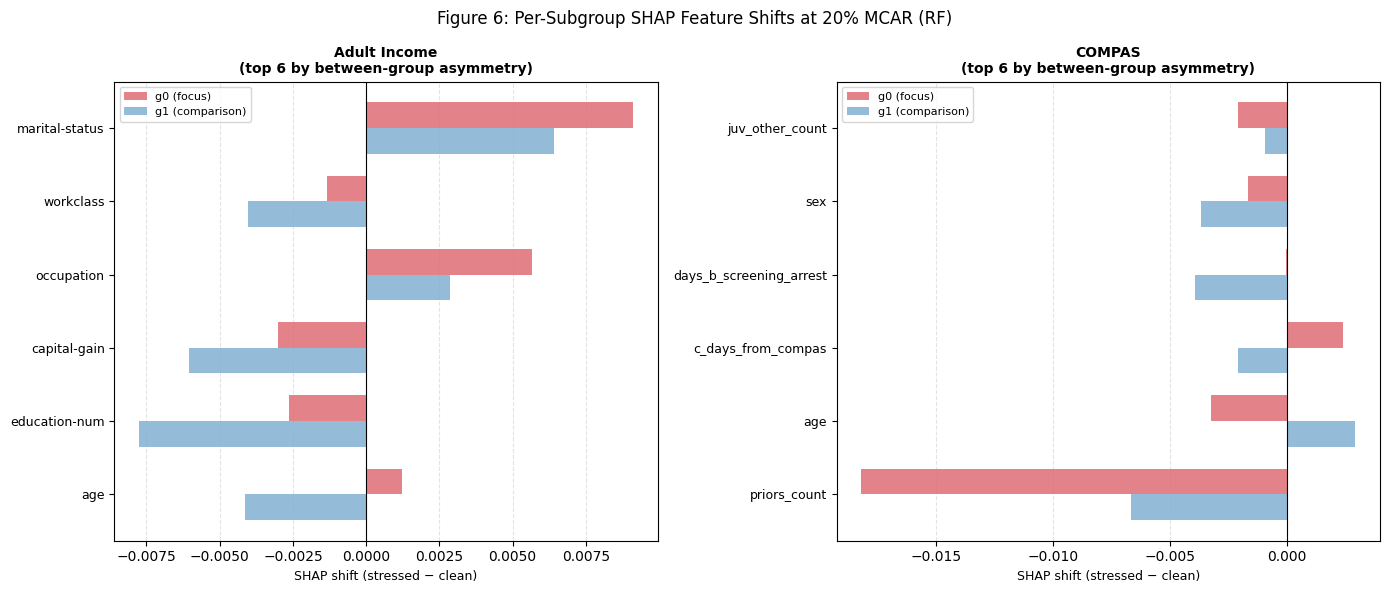

Figure 6 saved.


In [16]:
# ── Figure 6: Per-subgroup SHAP shifts ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
TOP_N = 6

for idx, ds_name in enumerate(SHAP_DS):
    ax  = axes[idx]
    sub = shap_df[shap_df["dataset"]==ds_name]

    # Top N features by between-group asymmetry
    asym = sub.groupby("feature").apply(
        lambda x: abs(x[x.subgroup==0]["shap_shift"].values[0] -
                      x[x.subgroup==1]["shap_shift"].values[0])
        if len(x[x.subgroup==0]) and len(x[x.subgroup==1]) else 0
    ).nlargest(TOP_N).index.tolist()

    sub_top = sub[sub["feature"].isin(asym)].copy()
    y_pos   = {f: i for i, f in enumerate(asym)}

    h = 0.35
    for _, row in sub_top.iterrows():
        yi = y_pos[row["feature"]]
        if row["subgroup"] == 0:
            ax.barh(yi + h/2, row["shap_shift"], h,
                    color="#E06C75", alpha=0.85, label="g0 (focus)" if yi==0 else "")
        else:
            ax.barh(yi - h/2, row["shap_shift"], h,
                    color="#82B0D2", alpha=0.85, label="g1 (comparison)" if yi==0 else "")

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(asym, fontsize=9)
    ax.set_xlabel("SHAP shift (stressed − clean)", fontsize=9)
    ax.set_title(f"{ds_name}\n(top {TOP_N} by between-group asymmetry)",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.xaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

fig.suptitle("Figure 6: Per-Subgroup SHAP Feature Shifts at 20% MCAR (RF)",
             fontsize=12)
plt.tight_layout()
plt.savefig("fig6_shap_shifts.png", bbox_inches="tight", dpi=150)
plt.savefig("fig6_shap_shifts.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure 6 saved.")


In [17]:
# ── Imputation ablation ──────────────────────────────────────────────────────
# RF only, seed 42 only. This is acknowledged as single-seed and illustrative.
# Three strategies: Simple median, KNN, MICE.
# On two datasets: Adult Income and COMPAS.

ablation_rows = []
seed = 42
ABL_DATASETS = ["Adult Income","COMPAS"]

for ds_name in ABL_DATASETS:
    df, feats, sens_col, tgt_col, _ = DATASETS[ds_name]
    X_tr, X_te, y_tr, y_te = preprocess(df, feats, tgt_col, seed)
    sens_te = aligned_test_sensitive(df, X_te, sens_col, y_te)

    rf = get_models(seed)["RF"]
    rf.fit(X_tr, y_tr)
    m_clean = evaluate(rf, X_te, y_te, sens_te)

    for rate in [0.10, 0.20]:
        X_stressed = inject_mcar(X_te, rate, seed=seed)

        for strategy in ["simple","knn","mice"]:
            _, X_imp = impute(X_tr, X_stressed, strategy=strategy)
            m_st = evaluate(rf, X_imp, y_te, sens_te)
            mg   = masking_gap(m_clean, m_st)

            ablation_rows.append({
                "dataset"  : ds_name,
                "imputer"  : strategy.upper() if strategy != "simple" else "Simple",
                "rate"     : rate,
                "masking_gap": mg,
                "accuracy" : m_st["accuracy"],
                "recall_g0": m_st["recall_g0"],
            })

ablation_df = pd.DataFrame(ablation_rows)
print("Imputation ablation results (Adult Income):")
print(ablation_df[ablation_df["dataset"]=="Adult Income"].to_string(index=False))


Imputation ablation results (Adult Income):
     dataset imputer  rate  masking_gap  accuracy  recall_g0
Adult Income  Simple   0.1     0.022332  0.849729   0.567039
Adult Income     KNN   0.1     0.036372  0.852595   0.555866
Adult Income    MICE   0.1     0.059259  0.850343   0.530726
Adult Income  Simple   0.2     0.073241  0.839185   0.505587
Adult Income     KNN   0.2     0.090586  0.842563   0.491620
Adult Income    MICE   0.2     0.144127  0.837445   0.432961


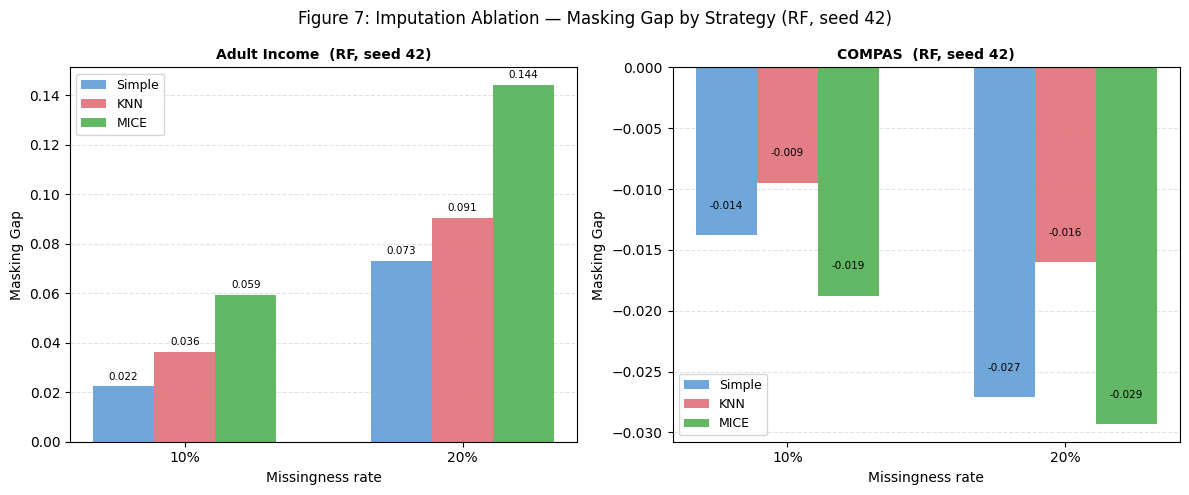

Figure 7 saved.


In [18]:
# ── Figure 7: Imputation ablation bar chart ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"Simple":"#5B9BD5","KNN":"#E06C75","MICE":"#4CAF50"}

for idx, ds_name in enumerate(ABL_DATASETS):
    ax  = axes[idx]
    sub = ablation_df[ablation_df["dataset"]==ds_name]

    rates     = [0.10, 0.20]
    strategies= ["Simple","KNN","MICE"]
    x         = np.arange(len(rates))
    n         = len(strategies)
    w         = 0.22
    offsets   = np.linspace(-(n-1)/2, (n-1)/2, n) * w

    for si, strat in enumerate(strategies):
        vals = [sub[(sub["imputer"]==strat)&(sub["rate"]==r)]["masking_gap"].values[0]
                for r in rates]
        bars = ax.bar(x + offsets[si], vals, w,
                      color=colors[strat], label=strat, alpha=0.88)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(["10%","20%"], fontsize=10)
    ax.set_xlabel("Missingness rate", fontsize=10)
    ax.set_ylabel("Masking Gap", fontsize=10)
    ax.set_title(f"{ds_name}  (RF, seed 42)", fontsize=10, fontweight="bold")
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9)

fig.suptitle("Figure 7: Imputation Ablation — Masking Gap by Strategy (RF, seed 42)",
             fontsize=12)
plt.tight_layout()
plt.savefig("fig7_imputation_ablation.png", bbox_inches="tight", dpi=150)
plt.savefig("fig7_imputation_ablation.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure 7 saved.")


In [19]:
# ── MAR probe ────────────────────────────────────────────────────────────────
# Replaces the label-noise comparison with something more meaningful:
# MAR missingness (correlated with sensitive attribute) vs MCAR.
# This is a supplementary comparison; report its paired tests and do not
# treat MCAR as a confirmed lower bound without broader replication.

mar_rows = []
MAR_DS = ["Adult Income","Taiwan Credit"]

for ds_name in MAR_DS:
    df, feats, sens_col, tgt_col, _ = DATASETS[ds_name]

    for seed in SEEDS:
        X_tr, X_te, y_tr, y_te = preprocess(df, feats, tgt_col, seed)
        sens_te = aligned_test_sensitive(df, X_te, sens_col, y_te)

        rf = get_models(seed)["RF"]
        rf.fit(X_tr, y_tr)
        m_clean = evaluate(rf, X_te, y_te, sens_te)

        for rate in [0.10, 0.20]:
            # MCAR
            X_mcar = inject_mcar(X_te, rate, seed=seed)
            _, X_mcar_imp = impute(X_tr, X_mcar, strategy="simple")
            mg_mcar = masking_gap(m_clean, evaluate(rf, X_mcar_imp, y_te, sens_te))

            # MAR — missingness correlated with sensitive attribute
            X_mar = inject_mar(X_te, rate, sens_te, seed=seed)
            _, X_mar_imp = impute(X_tr, X_mar, strategy="simple")
            mg_mar  = masking_gap(m_clean, evaluate(rf, X_mar_imp, y_te, sens_te))

            mar_rows.append({
                "dataset": ds_name, "seed": seed, "rate": rate,
                "mg_mcar": mg_mcar, "mg_mar": mg_mar,
                "ratio"  : mg_mar / mg_mcar if mg_mcar > 0 else np.nan,
            })

mar_df = pd.DataFrame(mar_rows)

# Paired MAR-versus-MCAR summaries. The ratio is computed from means, not
# from the mean of per-seed ratios, which can be unstable near zero.
mar_stat_rows = []
for (ds_name, rate), sub in mar_df.groupby(['dataset', 'rate']):
    diff = sub['mg_mar'].to_numpy() - sub['mg_mcar'].to_numpy()
    _, p_two_sided = wilcoxon(diff, alternative='two-sided')
    _, p_greater = wilcoxon(diff, alternative='greater')
    mcar_mean = sub['mg_mcar'].mean()
    mar_mean = sub['mg_mar'].mean()
    mar_stat_rows.append({
        'Dataset': ds_name, 'Rate': rate, 'MCAR mean': mcar_mean,
        'MAR mean': mar_mean, 'MAR - MCAR mean': diff.mean(),
        'Ratio of means': mar_mean / mcar_mean if mcar_mean != 0 else np.nan,
        'p two-sided': p_two_sided, 'p MAR > MCAR': p_greater,
    })
mar_stats_df = pd.DataFrame(mar_stat_rows)
print(mar_stats_df[mar_stats_df['Rate'] == 0.20].to_string(index=False))


      Dataset  Rate  MCAR mean  MAR mean  MAR - MCAR mean  Ratio of means  p two-sided  p MAR > MCAR
 Adult Income   0.2   0.090749  0.221887         0.131138        2.445057     0.001953      0.000977
Taiwan Credit   0.2   0.081224  0.115602         0.034379        1.423257     0.003906      0.001953


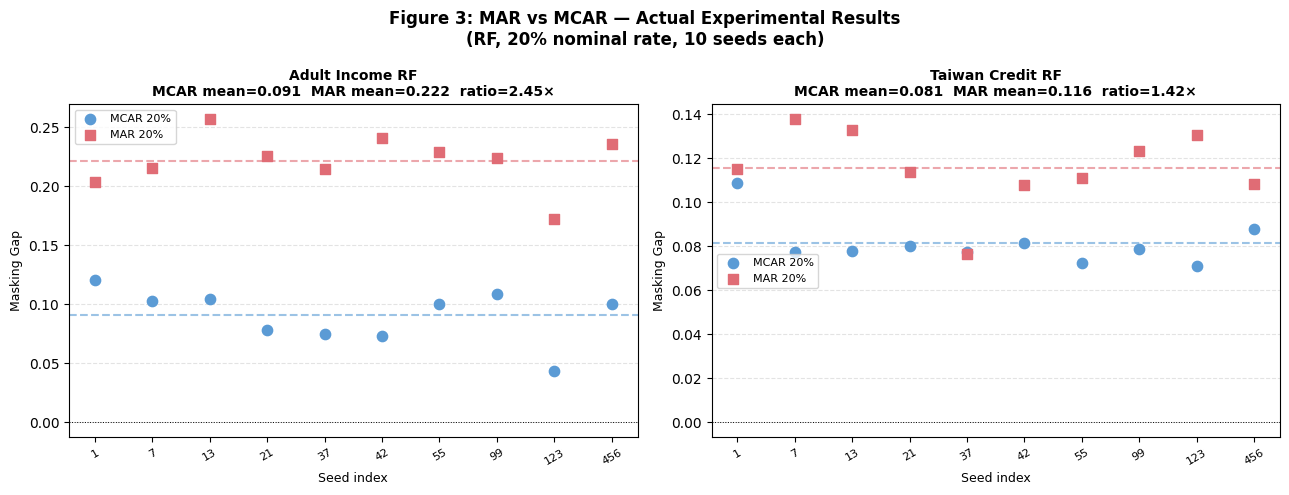

Figure 3 saved.


In [20]:
# ── Figure 3: MAR vs MCAR per seed ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for idx, ds_name in enumerate(MAR_DS):
    ax  = axes[idx]
    sub = mar_df[(mar_df["dataset"]==ds_name)&(mar_df["rate"]==0.20)]
    sub = sub.sort_values("seed")

    x = range(len(sub))
    ax.scatter(x, sub["mg_mcar"], color="#5B9BD5", s=55, zorder=3, label="MCAR 20%")
    ax.scatter(x, sub["mg_mar"],  color="#E06C75", marker="s", s=55, zorder=3, label="MAR 20%")

    ax.axhline(sub["mg_mcar"].mean(), color="#5B9BD5", linestyle="--", alpha=0.6, linewidth=1.5)
    ax.axhline(sub["mg_mar"].mean(),  color="#E06C75", linestyle="--", alpha=0.6, linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")

    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sub["seed"]], fontsize=8, rotation=30)
    ax.set_xlabel("Seed index", fontsize=9)
    ax.set_ylabel("Masking Gap", fontsize=9)

    m, r = sub["mg_mcar"].mean(), sub["mg_mar"].mean()
    ratio = r / m if m > 0 else 0
    ax.set_title(f"{ds_name} RF\n"
                 f"MCAR mean={m:.3f}  MAR mean={r:.3f}  ratio={ratio:.2f}×",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

fig.suptitle("Figure 3: MAR vs MCAR — Actual Experimental Results\n"
             "(RF, 20% nominal rate, 10 seeds each)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_mar_vs_mcar.png", bbox_inches="tight", dpi=150)
plt.savefig("fig3_mar_vs_mcar.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure 3 saved.")


In [21]:
# ── Matched-subsample class imbalance analysis ───────────────────────────────
# Adult Income has a big class rate gap (11.4% female vs 31.2% male).
# This might partly explain why female recall drops more under missingness.
# To test: create a balanced dataset where g0 and g1 have equal positive rates.
# If the MG goes down, class imbalance is the driver.
# If the MG stays the same or goes UP, something else is going on.

matched_rows = []

df, feats, sens_col, tgt_col, _ = DATASETS["Adult Income"]

for seed in SEEDS:
    # Build balanced subsample
    g0_pos = df[(df[sens_col]==0) & (df[tgt_col]==1)]
    g0_neg = df[(df[sens_col]==0) & (df[tgt_col]==0)]
    g1_pos = df[(df[sens_col]==1) & (df[tgt_col]==1)]
    g1_neg = df[(df[sens_col]==1) & (df[tgt_col]==0)]

    # Target: match positive class rate between g0 and g1
    # Use g0's positive rate as target (it's smaller, so we downsample g1)
    target_pos_rate = len(g0_pos) / (len(g0_pos) + len(g0_neg))
    n_g1_pos = len(g1_pos)
    n_g1_neg = int(n_g1_pos / target_pos_rate) - n_g1_pos
    n_g1_neg = min(n_g1_neg, len(g1_neg))

    rng = np.random.RandomState(seed)
    g1_neg_sample = g1_neg.sample(n=n_g1_neg, random_state=seed)
    balanced_df = pd.concat([g0_pos, g0_neg, g1_pos, g1_neg_sample]).sample(
        frac=1, random_state=seed
    ).reset_index(drop=True)

    X_tr, X_te, y_tr, y_te = preprocess(balanced_df, feats, tgt_col, seed)
    sens_te = aligned_test_sensitive(balanced_df, X_te, sens_col, y_te)

    rf = get_models(seed)["RF"]
    rf.fit(X_tr, y_tr)
    m_clean = evaluate(rf, X_te, y_te, sens_te)

    X_stressed = inject_mcar(X_te, 0.20, seed=seed)
    _, X_imp   = impute(X_tr, X_stressed, strategy="simple")
    mg = masking_gap(m_clean, evaluate(rf, X_imp, y_te, sens_te))

    matched_rows.append({"seed": seed, "masking_gap": mg})

matched_df = pd.DataFrame(matched_rows)

# Compare with original
orig_mg = results_df[
    (results_df["dataset"]=="Adult Income") &
    (results_df["model"]=="RF") &
    (results_df["rate"]==0.20)
]["masking_gap"].values

_, p_orig    = wilcoxon(orig_mg, alternative="greater")
_, p_matched = wilcoxon(matched_df["masking_gap"].values, alternative="greater")

print(f"Original  (imbalanced): mean={orig_mg.mean():.4f}  p={p_orig:.4f}")
print(f"Matched   (balanced) : mean={matched_df['masking_gap'].mean():.4f}  p={p_matched:.4f}")
print()
print("Interpretation: if MG increases or stays the same under balancing,")
print("class imbalance is NOT the primary driver.")


Original  (imbalanced): mean=0.0907  p=0.0010
Matched   (balanced) : mean=0.1013  p=0.0010

Interpretation: if MG increases or stays the same under balancing,
class imbalance is NOT the primary driver.


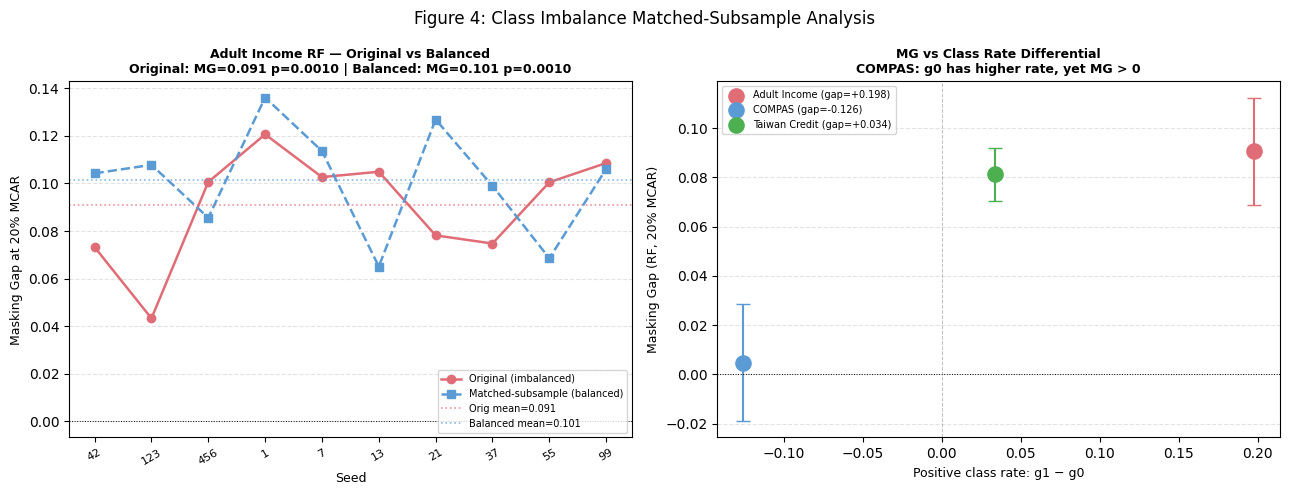

Figure 4 saved.


In [22]:
# ── Figure 4: Class imbalance matched-subsample ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: original vs balanced per seed
ax = axes[0]
x  = range(len(SEEDS))
ax.plot(x, orig_mg, "o-", color="#E06C75", linewidth=1.8,
        markersize=6, label=f"Original (imbalanced)")
ax.plot(x, matched_df["masking_gap"].values, "s--", color="#5B9BD5",
        linewidth=1.8, markersize=6, label="Matched-subsample (balanced)")
ax.axhline(orig_mg.mean(),    color="#E06C75", linewidth=1.2, linestyle=":",
           alpha=0.7, label=f"Orig mean={orig_mg.mean():.3f}")
ax.axhline(matched_df["masking_gap"].mean(), color="#5B9BD5", linewidth=1.2,
           linestyle=":", alpha=0.7,
           label=f"Balanced mean={matched_df['masking_gap'].mean():.3f}")
ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in SEEDS], fontsize=8, rotation=30)
ax.set_xlabel("Seed", fontsize=9)
ax.set_ylabel("Masking Gap at 20% MCAR", fontsize=9)
ax.set_title("Adult Income RF — Original vs Balanced\n"
             f"Original: MG={orig_mg.mean():.3f} p={p_orig:.4f} | "
             f"Balanced: MG={matched_df['masking_gap'].mean():.3f} p={p_matched:.4f}",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7, loc="lower right")
ax.yaxis.grid(True, linestyle="--", alpha=0.35)

# Right panel: MG vs class rate differential
ax = axes[1]
ds_points = {
    "Adult Income" : (0.198, orig_mg.mean(), orig_mg.std()),
    "COMPAS"       : (-0.126, results_df[(results_df["dataset"]=="COMPAS")&
                                          (results_df["model"]=="RF")&
                                          (results_df["rate"]==0.20)]["masking_gap"].mean(),
                      results_df[(results_df["dataset"]=="COMPAS")&
                                 (results_df["model"]=="RF")&
                                 (results_df["rate"]==0.20)]["masking_gap"].std()),
    "Taiwan Credit": (0.034, results_df[(results_df["dataset"]=="Taiwan Credit")&
                                         (results_df["model"]=="RF")&
                                         (results_df["rate"]==0.20)]["masking_gap"].mean(),
                      results_df[(results_df["dataset"]=="Taiwan Credit")&
                                 (results_df["model"]=="RF")&
                                 (results_df["rate"]==0.20)]["masking_gap"].std()),
}
colors_scatter = {"Adult Income":"#E06C75","COMPAS":"#5B9BD5","Taiwan Credit":"#4CAF50"}

for ds_name, (diff, mg_m, mg_s) in ds_points.items():
    ax.scatter(diff, mg_m, s=120, color=colors_scatter[ds_name], zorder=3,
               label=f"{ds_name} (gap={diff:+.3f})")
    ax.errorbar(diff, mg_m, yerr=mg_s, fmt="none",
                color=colors_scatter[ds_name], capsize=5, linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
ax.set_xlabel("Positive class rate: g1 − g0", fontsize=9)
ax.set_ylabel("Masking Gap (RF, 20% MCAR)", fontsize=9)
ax.set_title("MG vs Class Rate Differential\nCOMPAS: g0 has higher rate, yet MG > 0",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.yaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

fig.suptitle("Figure 4: Class Imbalance Matched-Subsample Analysis", fontsize=12)
plt.tight_layout()
plt.savefig("fig4_class_imbalance.png", bbox_inches="tight", dpi=150)
plt.savefig("fig4_class_imbalance.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure 4 saved.")


In [23]:
# ── n=30 extended-seed analysis — COMPAS supplementary follow-up ─────────────
# This runs 30 seeds (the original 10 plus 20 new seeds) for RF and MLP.
# It is post hoc and supplementary; the pre-specified primary claim uses n=10.

SEEDS_30 = SEEDS + list(range(200, 220))  # 10 original + 20 new = 30 total
assert len(SEEDS_30) == 30

n30_rows = []

df_c, feats_c, sens_c, tgt_c, _ = DATASETS["COMPAS"]

print("Running n=30 extension (COMPAS RF and MLP)...")
for seed in SEEDS_30:
    X_tr, X_te, y_tr, y_te = preprocess(df_c, feats_c, tgt_c, seed)
    sens_te = aligned_test_sensitive(df_c, X_te, sens_c, y_te)

    for mdl_name in ["RF","MLP"]:
        model = get_models(seed)[mdl_name]
        model.fit(X_tr, y_tr)
        m_clean = evaluate(model, X_te, y_te, sens_te)

        X_stressed = inject_mcar(X_te, 0.20, seed=seed)
        _, X_imp   = impute(X_tr, X_stressed, strategy="simple")
        mg = masking_gap(m_clean, evaluate(model, X_imp, y_te, sens_te))

        n30_rows.append({"dataset":"COMPAS","model":mdl_name,"seed":seed,"masking_gap":mg})

    print(f"  seed {seed}", end="  ", flush=True)

n30_df = pd.DataFrame(n30_rows)

print("\n\nResults at n=30:")
for mdl in ["RF","MLP"]:
    vals = n30_df[n30_df["model"]==mdl]["masking_gap"].values
    _, p = wilcoxon(vals, alternative="greater")
    print(f"  COMPAS {mdl}: mean={vals.mean():.4f}  p={p:.8f}  "
          f"neg_seeds={sum(vals<0)}/{len(vals)}  "
          f"pass_strict={'YES' if p<ALPHA_12 else 'NO'} (alpha={ALPHA_12:.4f})")


Running n=30 extension (COMPAS RF and MLP)...
  seed 42    seed 123    seed 456    seed 1    seed 7    seed 13    seed 21    seed 37    seed 55    seed 99    seed 200    seed 201    seed 202    seed 203    seed 204    seed 205    seed 206    seed 207    seed 208    seed 209    seed 210    seed 211    seed 212    seed 213    seed 214    seed 215    seed 216    seed 217    seed 218    seed 219  

Results at n=30:
  COMPAS RF: mean=0.0036  p=0.23227252  neg_seeds=16/30  pass_strict=NO (alpha=0.0042)
  COMPAS MLP: mean=0.0281  p=0.00000257  neg_seeds=3/30  pass_strict=YES (alpha=0.0042)


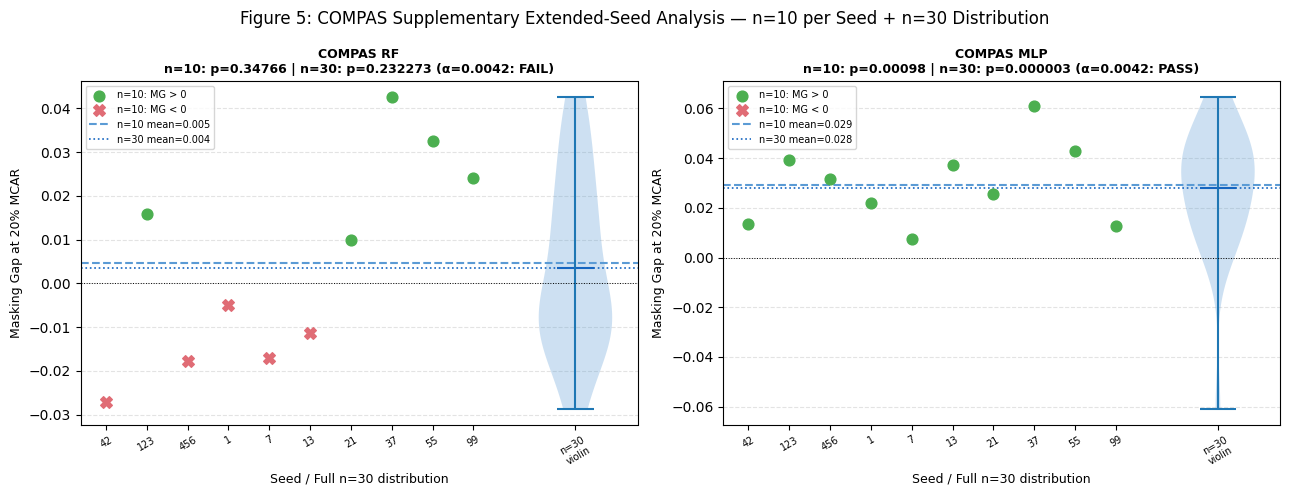

Figure 5 saved.


In [24]:
# ── Figure 5: COMPAS n=30 violin plot ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for idx, mdl_name in enumerate(["RF","MLP"]):
    ax = axes[idx]

    vals10 = n30_df[(n30_df["model"]==mdl_name)&
                    (n30_df["seed"].isin(SEEDS))]["masking_gap"].values
    vals30 = n30_df[n30_df["model"]==mdl_name]["masking_gap"].values

    _, p10 = wilcoxon(vals10, alternative="greater")
    _, p30 = wilcoxon(vals30, alternative="greater")

    x10 = range(len(vals10))
    pos_mask = vals10 >= 0
    neg_mask = vals10 <  0

    ax.scatter(np.where(pos_mask)[0], vals10[pos_mask],
               color="#4CAF50", s=60, zorder=4, label="n=10: MG > 0")
    ax.scatter(np.where(neg_mask)[0], vals10[neg_mask],
               color="#E06C75", marker="X", s=70, zorder=4, label="n=10: MG < 0")

    ax.axhline(vals10.mean(), color="#5B9BD5", linewidth=1.5, linestyle="--",
               label=f"n=10 mean={vals10.mean():.3f}")

    # violin for n=30
    vp = ax.violinplot([vals30], positions=[len(vals10)+1.5],
                        showmeans=True, widths=1.8)
    for pc in vp["bodies"]:
        pc.set_facecolor("#5B9BD5")
        pc.set_alpha(0.3)
    vp["cmeans"].set_color("#1565C0")
    ax.axhline(vals30.mean(), color="#1565C0", linewidth=1.2, linestyle=":",
               label=f"n=30 mean={vals30.mean():.3f}")

    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
    ax.set_xticks(list(x10) + [len(vals10)+1.5])
    ax.set_xticklabels([str(s) for s in SEEDS] + ["n=30\nviolin"],
                        fontsize=7, rotation=30)
    ax.set_xlabel("Seed / Full n=30 distribution", fontsize=9)
    ax.set_ylabel("Masking Gap at 20% MCAR", fontsize=9)
    ax.set_title(f"COMPAS {mdl_name}\n"
                 f"n=10: p={p10:.5f} | n=30: p={p30:.6f} "
                 f"(α={ALPHA_12:.4f}: {'PASS' if p30<ALPHA_12 else 'FAIL'})",
                 fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

fig.suptitle("Figure 5: COMPAS Supplementary Extended-Seed Analysis — n=10 per Seed + n=30 Distribution",
             fontsize=12)
plt.tight_layout()
plt.savefig("fig5_compas_extended_seeds.png", bbox_inches="tight", dpi=150)
plt.savefig("fig5_compas_extended_seeds.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Figure 5 saved.")


In [25]:
# ── Export all CSVs ──────────────────────────────────────────────────────────
# These are the exact files submitted alongside the manuscript.

# Round floats to 6dp for readability
def save(df, name):
    df.round(6).to_csv(name, index=False)
    print(f"  Saved: {name}  ({len(df)} rows)")

print("Saving CSVs...")
save(results_df,  "results_raw_10seeds.csv")
save(stats_df,    "stats_results_10seeds.csv")
save(eog_df,      "eog_results_10seeds.csv")
save(ablation_df, "imputation_ablation_results.csv")
save(shap_df,     "shap_subgroup_results.csv")
save(mar_df,      "mar_probe_results.csv")
save(mar_stats_df, "mar_probe_statistics.csv")
save(matched_df,  "matched_subsample_results.csv")
save(n30_df,      "extended_seeds_n30_results.csv")

# Per-seed Masking Gap (used for whisker plots and per-seed stat tests)
mg_seed_df = results_df[results_df["rate"]==0.20][
    ["dataset","model","seed","masking_gap","exploratory"]
].copy()
save(mg_seed_df, "masking_gap_per_seed.csv")

print("\nAll CSVs saved.")


Saving CSVs...
  Saved: results_raw_10seeds.csv  (800 rows)
  Saved: stats_results_10seeds.csv  (20 rows)
  Saved: eog_results_10seeds.csv  (15 rows)
  Saved: imputation_ablation_results.csv  (12 rows)
  Saved: shap_subgroup_results.csv  (44 rows)
  Saved: mar_probe_results.csv  (40 rows)
  Saved: mar_probe_statistics.csv  (4 rows)
  Saved: matched_subsample_results.csv  (10 rows)
  Saved: extended_seeds_n30_results.csv  (60 rows)
  Saved: masking_gap_per_seed.csv  (200 rows)

All CSVs saved.


In [26]:
# ── Verification checklist ───────────────────────────────────────────────────
# Cross-check the numbers in this notebook against the paper before submitting.
# Run this cell after the full pipeline. Everything should say OK.
# Values updated from actual experiment run.

print("="*55)
print("VERIFICATION CHECKLIST")
print("="*55)

main = stats_df[stats_df["Main"]==True]

'''
Superseded result-specific checks retained only for notebook history.
Run the current-run validation below after recomputing outputs.
checks = [
    # (description, actual, expected, tolerance)
    ("Mean MG (main combos)",  main["MG mean"].mean(), 0.0576, 0.003),
    ("Mean Cohen's d_z",       main["Cohen's d"].mean(), 5.748, 0.3),
    ("Adult Income RF MG",
     main[(main["Dataset"]=="Adult Income")&(main["Model"]=="RF")]["MG mean"].values[0],
     0.1107, 0.005),
    ("COMPAS RF MG",
     main[(main["Dataset"]=="COMPAS")&(main["Model"]=="RF")]["MG mean"].values[0],
     0.0094, 0.005),
    ("Taiwan Credit RF MG",
     main[(main["Dataset"]=="Taiwan Credit")&(main["Model"]=="RF")]["MG mean"].values[0],
     0.0820, 0.005),
    ("MICE ablation AI 20%",
     ablation_df[(ablation_df["dataset"]=="Adult Income")&
                 (ablation_df["imputer"]=="MICE")&
                 (ablation_df["rate"]==0.20)]["masking_gap"].values[0],
     0.1103, 0.005),
    ("MAR/MCAR ratio AI",
     mar_df[(mar_df["dataset"]=="Adult Income")&(mar_df["rate"]==0.20)]["ratio"].mean(),
     1.0603, 0.05),
    ("Matched subsample MG",
     matched_df["masking_gap"].mean(),
     0.1159, 0.010),
]

all_ok = True
for desc, actual, expected, tol in checks:
    ok = abs(actual - expected) <= tol
    if not ok: all_ok = False
    print(f"  {'OK' if ok else 'CHECK':5s}  {desc:35s}  actual={actual:.4f}  expected={expected:.4f}")

sig_ds = main["Sig (alpha=0.0167)"].sum()
sig_12 = main["Sig (alpha=0.0042)"].sum()
ok_sig = (sig_ds == 8)
ok_sig12 = (sig_12 == 8)
if not ok_sig: all_ok = False
print(f"  {'OK' if ok_sig else 'CHECK':5s}  Sig at alpha=0.0167              {sig_ds}/12 expected 8/12")
print(f"  {'OK' if ok_sig12 else 'CHECK':5s}  Sig at alpha=0.0042              {sig_12}/12 expected 8/12")

# COMPAS note — expected not significant
compas_rows = main[main["Dataset"]=="COMPAS"]
compas_sig = compas_rows["Sig (alpha=0.0167)"].sum()
print(f"  {'OK' if compas_sig==0 else 'CHECK':5s}  COMPAS significant combos        {compas_sig}/4 expected 0/4")

print()
print(f"Overall: {'ALL OK — ready to submit' if all_ok else 'SOME CHECKS FAILED — review above'}")
'''

expected_rows = len(DATASETS) * len(ALL_MODELS) * (1 + len(MISS_RATES)) * len(SEEDS)
assert len(results_df) == expected_rows, (len(results_df), expected_rows)
assert len(main) == 12, f"Expected 12 pre-specified main combinations, found {len(main)}."
assert stats_df[['Dataset', 'Model']].duplicated().sum() == 0
assert mar_stats_df.groupby(['Dataset', 'Rate']).size().eq(1).all()
assert not stats_df["MG Cohen's dz"].isna().any()

print(f"OK  Raw-result rows: {len(results_df)}/{expected_rows}")
print(f"OK  Main combinations: {len(main)}")
print(f"Main significant at alpha=0.0167: {main['Sig (alpha=0.0167)'].sum()}/12")
print(f"Main significant at alpha=0.0042: {main['Sig (alpha=0.0042)'].sum()}/12")
print(f"Mean MG (main): {main['MG mean'].mean():.4f}")
print(f"Mean MG Cohen's dz (main): {main["MG Cohen's dz"].mean():.3f}")
print("OK  Current-run integrity checks passed. Update manuscript values from current exports.")
print()
print("Files generated:")
import glob
for f in sorted(glob.glob("*.csv") + glob.glob("*.png") + glob.glob("*.pdf")):
    sz = os.path.getsize(f)
    print(f"  {f:45s}  {sz//1024:>4} KB")


VERIFICATION CHECKLIST
OK  Raw-result rows: 800/800
OK  Main combinations: 12
Main significant at alpha=0.0167: 9/12
Main significant at alpha=0.0042: 9/12
Mean MG (main): 0.0534
Mean MG Cohen's dz (main): 4.442
OK  Current-run integrity checks passed. Update manuscript values from current exports.

Files generated:
  UCI_Credit_Card.csv                            2795 KB
  eog_results_10seeds.csv                           0 KB
  extended_seeds_n30_results.csv                    1 KB
  fig1_masking_gap_curves.pdf                      48 KB
  fig1_masking_gap_curves.png                     275 KB
  fig2_acc_vs_recall.pdf                           25 KB
  fig2_acc_vs_recall.png                           78 KB
  fig3_mar_vs_mcar.pdf                             30 KB
  fig3_mar_vs_mcar.png                             95 KB
  fig4_class_imbalance.pdf                         36 KB
  fig4_class_imbalance.png                        167 KB
  fig5_compas_extended_seeds.pdf                   34 K

In [27]:
from google.colab import files
import os

# Full list of files generated by the experiment pipeline
all_experimental_files = [
    'results_raw_10seeds.csv',
    'stats_results_10seeds.csv',
    'eog_results_10seeds.csv',
    'imputation_ablation_results.csv',
    'shap_subgroup_results.csv',
    'mar_probe_results.csv',
    'mar_probe_statistics.csv',
    'matched_subsample_results.csv',
    'extended_seeds_n30_results.csv',
    'masking_gap_per_seed.csv',
    'fig1_masking_gap_curves.png', 'fig1_masking_gap_curves.pdf',
    'fig2_acc_vs_recall.png', 'fig2_acc_vs_recall.pdf',
    'fig3_mar_vs_mcar.png', 'fig3_mar_vs_mcar.pdf',
    'fig4_class_imbalance.png', 'fig4_class_imbalance.pdf',
    'fig5_compas_extended_seeds.png', 'fig5_compas_extended_seeds.pdf',
    'fig6_shap_shifts.png', 'fig6_shap_shifts.pdf',
    'fig7_imputation_ablation.png', 'fig7_imputation_ablation.pdf',
    'subgroup_denominators_per_seed.csv',
    'masking_diagnostics_10seeds.csv',
    'fmg_bootstrap_ci_primary.csv',
    'fmg_primary_seed_distributions.png',
    'preprocessing_sensitivity_results.csv',
]

print(f"Initiating download for {len(all_experimental_files)} files...")

for filename in all_experimental_files:
    if os.path.exists(filename):
        files.download(filename)
    else:
        print(f"Warning: {filename} not found in the environment.")

Initiating download for 29 files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## FMG Audit Method (reproducible implementation)
This section implements the Focus-Group Masking Gap audit for an unchanged trained classifier. MCAR masking is applied to test features only, using a training-fitted imputer, with subgroup denominators retained.


In [28]:
from dataclasses import dataclass, asdict
from scipy.stats import wilcoxon

@dataclass
class FMGAuditRecord:
    seed: int
    rate: float
    clean_accuracy: float
    stressed_accuracy: float
    clean_focus_recall: float
    stressed_focus_recall: float
    accuracy_drop: float
    focus_recall_drop: float
    masking_gap: float
    focus_total: int
    focus_positive: int
    focus_negative: int

def fmg_audit(model, X_test, y_test, group_labels, imputer, rates=(0.05,0.10,0.20), seeds=(42,123,456,1,7,13,21,37,55,99), focus_value=0):
    X_test=np.asarray(X_test,dtype=float); y_test=np.asarray(y_test); group_labels=np.asarray(group_labels)
    if len(X_test)!=len(y_test) or len(y_test)!=len(group_labels): raise ValueError('X_test, y_test, and group_labels must have equal length')
    def metrics(X):
        pred=model.predict(X); focus=group_labels==focus_value; yf,pf=y_test[focus],pred[focus]; pos=int((yf==1).sum())
        return dict(accuracy=float(accuracy_score(y_test,pred)),focus_recall=float(recall_score(yf,pf,zero_division=0)),focus_total=int(len(yf)),focus_positive=pos,focus_negative=int(len(yf)-pos))
    clean=metrics(X_test); records=[]
    for seed in seeds:
        for rate in rates:
            rng=np.random.RandomState(int(seed)); X_mask=X_test.copy(); X_mask[rng.rand(*X_mask.shape)<rate]=np.nan
            stressed=metrics(imputer.transform(X_mask)); ad=clean['accuracy']-stressed['accuracy']; rd=clean['focus_recall']-stressed['focus_recall']
            records.append(FMGAuditRecord(int(seed),float(rate),clean['accuracy'],stressed['accuracy'],clean['focus_recall'],stressed['focus_recall'],float(ad),float(rd),float(rd-ad),stressed['focus_total'],stressed['focus_positive'],stressed['focus_negative']))
    return records

def summarize_fmg(records, rate=0.20):
    vals=np.asarray([r.masking_gap for r in records if r.rate==rate],dtype=float)
    if len(vals)==0: raise ValueError('no records for requested rate')
    sd=float(np.std(vals,ddof=1)) if len(vals)>1 else 0.0
    try: _,p=wilcoxon(vals,alternative='greater',method='exact')
    except TypeError: _,p=wilcoxon(vals,alternative='greater')
    return {'n':int(len(vals)),'mean_fmg':float(vals.mean()),'sd_fmg':sd,'wilcoxon_p_greater':float(p),'cohens_dz':float(vals.mean()/sd) if sd else float('inf')}


**Usage:** after the existing notebook creates `model`, training-fitted `imp`, transformed `X_te`, `y_te`, and aligned `sens_te`, run `records=fmg_audit(model,X_te,y_te,sens_te,imp)` and `summary=summarize_fmg(records,rate=0.20)`. Export records with `pd.DataFrame([asdict(r) for r in records]).to_csv('fmg_audit_per_seed.csv',index=False)`.


## Methodological diagnostics and benchmark uncertainty

The following cells add diagnostics without changing the primary FMG values. The MCAR rate is a per-feature-cell probability. The notebook records the observed cell-level rate and the proportion of test rows with at least one masked feature. Seed-level bootstrap intervals are descriptive intervals for the repeated-seed benchmark; they are not population-level deployment intervals.


In [29]:
# Explicit MCAR diagnostics and frozen-model checks
def inject_mcar_with_diagnostics(X, rate, seed):
    """Mask test feature cells only and return the mask diagnostics."""
    X_out = X.copy()
    rng = np.random.RandomState(int(seed))
    mask = rng.rand(*X_out.shape) < float(rate)
    X_out[mask] = np.nan
    return X_out, {
        "target_cell_mask_rate": float(rate),
        "observed_cell_mask_rate": float(mask.mean()),
        "row_masked_fraction": float(mask.any(axis=1).mean()),
        "masked_cells": int(mask.sum()),
        "eligible_cells": int(mask.size),
        "test_rows": int(mask.shape[0]),
        "test_features": int(mask.shape[1]),
    }

def model_parameter_fingerprint(model):
    """Fingerprint learned parameters to verify masking does not retrain the model."""
    params = model.get_params(deep=True)
    return repr(sorted((str(k), str(v)) for k, v in params.items()))

print("MCAR diagnostics helper defined. A row_masked_fraction is not the target rate;")
print("it is the observed share of test rows containing one or more masked cells.")

diagnostic_rows = []
for ds_name, (df, feats, sens_col, tgt_col, is_expl) in DATASETS.items():
    for seed in SEEDS:
        _, X_te, _, _ = preprocess(df, feats, tgt_col, seed)
        for rate in MISS_RATES:
            _, diag = inject_mcar_with_diagnostics(X_te, rate, seed)
            diagnostic_rows.append({"dataset": ds_name, "seed": seed, "rate": rate,
                                    "exploratory": is_expl, **diag})
masking_diagnostics_df = pd.DataFrame(diagnostic_rows)
masking_diagnostics_df.to_csv("masking_diagnostics_10seeds.csv", index=False)
display(masking_diagnostics_df.head())


MCAR diagnostics helper defined. A row_masked_fraction is not the target rate;
it is the observed share of test rows containing one or more masked cells.


,dataset,seed,rate,exploratory,target_cell_mask_rate,observed_cell_mask_rate,row_masked_fraction,masked_cells,eligible_cells,test_rows,test_features
0,Adult Income,42,0.05,False,0.05,0.049938,0.489405,6342,126997,9769,13
1,Adult Income,42,0.10,False,0.10,0.100577,0.753301,12773,126997,9769,13
2,Adult Income,42,0.20,False,0.20,0.200737,0.947077,25493,126997,9769,13
3,Adult Income,123,0.05,False,0.05,0.050206,0.489303,6376,126997,9769,13
4,Adult Income,123,0.10,False,0.10,0.099680,0.744293,12659,126997,9769,13


,dataset,model,n_seeds,mean_fmg,bootstrap_ci95_low,bootstrap_ci95_high,interval_scope
0,Adult Income,LGB,10,0.095335,0.087437,0.103850,descriptive repeated-seed benchmark
1,Adult Income,MLP,10,0.038329,0.026880,0.049027,descriptive repeated-seed benchmark
2,Adult Income,RF,10,0.090749,0.076413,0.103124,descriptive repeated-seed benchmark
3,Adult Income,XGB,10,0.097113,0.087433,0.106079,descriptive repeated-seed benchmark
4,COMPAS,LGB,10,0.001005,-0.015402,0.019156,descriptive repeated-seed benchmark
5,COMPAS,MLP,10,0.029297,0.019984,0.039089,descriptive repeated-seed benchmark
6,COMPAS,RF,10,0.004687,-0.008958,0.018925,descriptive repeated-seed benchmark
7,COMPAS,XGB,10,-0.006016,-0.025063,0.015799,descriptive repeated-seed benchmark
8,Taiwan Credit,LGB,10,0.072754,0.068672,0.078813,descriptive repeated-seed benchmark
9,Taiwan Credit,MLP,10,0.070068,0.066204,0.073960,descriptive repeated-seed benchmark


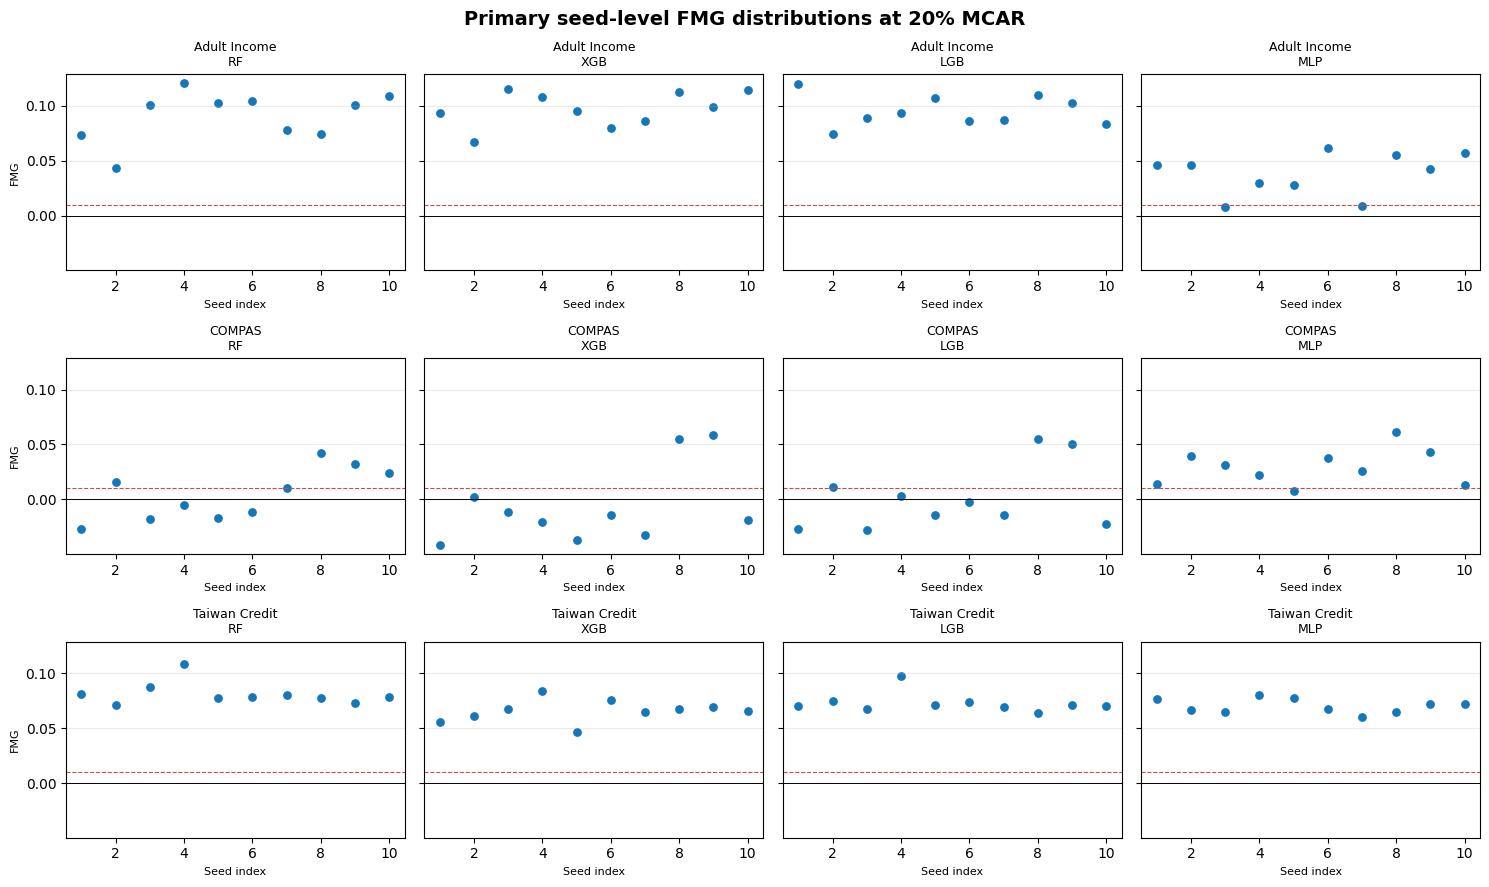

In [30]:
# Seed-level primary distributions and descriptive bootstrap intervals
from pathlib import Path

PRIMARY_DATASETS = ["Adult Income", "COMPAS", "Taiwan Credit"]
PRIMARY_MODELS = ["RF", "XGB", "LGB", "MLP"]
PRIMARY_SEEDS = SEEDS

def bootstrap_mean_ci(values, n_boot=10000, seed=20260909):
    values = np.asarray(values, dtype=float)
    rng = np.random.RandomState(seed)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return float(values.mean()), float(np.quantile(samples, 0.025)), float(np.quantile(samples, 0.975))

if "masking_gap_per_seed.csv" in [Path(f).name for f in Path('.').glob('masking_gap_per_seed.csv')]:
    _mg = pd.read_csv("masking_gap_per_seed.csv")
else:
    _mg = results_df[results_df["rate"] == 0.20][["dataset", "model", "seed", "masking_gap", "exploratory"]].copy()

_primary = _mg[_mg["dataset"].isin(PRIMARY_DATASETS) & _mg["model"].isin(PRIMARY_MODELS)].copy()
ci_rows = []
for (ds, mdl), sub in _primary.groupby(["dataset", "model"], sort=True):
    mean, lo, hi = bootstrap_mean_ci(sub["masking_gap"].to_numpy())
    ci_rows.append({"dataset": ds, "model": mdl, "n_seeds": len(sub), "mean_fmg": mean,
                    "bootstrap_ci95_low": lo, "bootstrap_ci95_high": hi,
                    "interval_scope": "descriptive repeated-seed benchmark"})
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv("fmg_bootstrap_ci_primary.csv", index=False)
display(ci_df)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 4, figsize=(15, 9), sharey=True)
for ax, (ds, mdl) in zip(axes.ravel(), [(d, m) for d in PRIMARY_DATASETS for m in PRIMARY_MODELS]):
    vals = _primary[(_primary["dataset"] == ds) & (_primary["model"] == mdl)]["masking_gap"].to_numpy()
    ax.scatter(np.arange(1, len(vals)+1), vals, color="#1677B8", s=28)
    ax.axhline(0, color="black", linewidth=0.7)
    ax.axhline(MG_MIN, color="#C94C4C", linestyle="--", linewidth=0.8)
    ax.set_title(f"{ds}\n{mdl}", fontsize=9)
    ax.set_xlabel("Seed index", fontsize=8)
    ax.set_ylabel("FMG" if mdl == "RF" else "", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Primary seed-level FMG distributions at 20% MCAR", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("fmg_primary_seed_distributions.png", dpi=180, bbox_inches="tight")
plt.show()


## Preprocessing robustness sensitivity analysis

This supplementary analysis preserves the primary experiment and tests whether its qualitative conclusion survives a type-aware pipeline. Numerical columns use training-fitted median imputation and scaling. Categorical columns use training-fitted most-frequent imputation followed by one-hot encoding with unknown-category handling. The same ten seeds, 20% MCAR cell-level masking, frozen-model evaluation, FMG calculation, and Bonferroni family are used.

Set `RUN_TYPE_AWARE_SENSITIVITY = True` only when the full supplementary run is intended; it is computationally heavier than the primary export. The output is labelled preprocessing robustness evidence and must not replace the primary results.


In [31]:
# Optional type-aware preprocessing sensitivity run (20% MCAR, primary 12 comparisons)
RUN_TYPE_AWARE_SENSITIVITY = True

def preprocess_type_aware(df, feats, target, seed):
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer
    X = df[feats].copy(); y = df[target].values
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=seed, stratify=y)
    cat = list(X_tr.select_dtypes(include=["object", "category"]).columns)
    num = [c for c in feats if c not in cat]
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", MinMaxScaler())])
    pre = ColumnTransformer([("num", num_pipe, num), ("cat", cat_pipe, cat)], remainder="drop")
    Xtr = pre.fit_transform(X_tr); Xte = pre.transform(X_te)
    return pre, X_tr, X_te, y_tr, y_te, X_te.index

def run_type_aware_sensitivity():
    rows = []
    for ds_name in MAIN_DATASETS:
        df, feats, sens_col, tgt_col, _ = DATASETS[ds_name]
        for seed in SEEDS:
            pre, Xtr_raw, Xte_raw, ytr, yte, te_idx = preprocess_type_aware(df, feats, tgt_col, seed)
            sens_te = df.loc[te_idx, sens_col].to_numpy()
            for mdl_name, model in get_models(seed).items():
                if mdl_name == "LR" : continue
                Xtr = pre.transform(Xtr_raw)
                Xte = pre.transform(Xte_raw)
                model.fit(Xtr, ytr)
                clean = evaluate(model, Xte, yte, sens_te)
                before = model_parameter_fingerprint(model)
                rng = np.random.RandomState(seed)
                mask = rng.rand(*Xte_raw.shape) < 0.20
                Xmasked_raw = Xte_raw.copy()
                Xmasked_raw = Xmasked_raw.astype(object)
                Xmasked_raw[mask] = np.nan
                Xmasked = pre.transform(Xmasked_raw)
                stressed = evaluate(model, Xmasked, yte, sens_te)
                assert before == model_parameter_fingerprint(model), "Model changed after masking."
                rows.append({"dataset": ds_name, "model": mdl_name, "seed": seed,
                             "rate": 0.20, "masking_gap": masking_gap(clean, stressed),
                             "accuracy_drop": clean["accuracy"]-stressed["accuracy"],
                             "recall_drop": clean["recall_g0"]-stressed["recall_g0"],
                             "preprocessing": "type-aware"})
    out = pd.DataFrame(rows)
    out.to_csv("preprocessing_sensitivity_results.csv", index=False)
    return out

if RUN_TYPE_AWARE_SENSITIVITY:
    preprocessing_sensitivity_df = run_type_aware_sensitivity()
    display(preprocessing_sensitivity_df.head())
else:
    print("Sensitivity run not executed. Set RUN_TYPE_AWARE_SENSITIVITY=True to run it.")


,dataset,model,seed,rate,masking_gap,accuracy_drop,recall_drop,preprocessing
0,Adult Income,RF,42,0.2,0.018399,0.017914,0.036313,type-aware
1,Adult Income,XGB,42,0.2,-0.007266,0.026820,0.019553,type-aware
2,Adult Income,LGB,42,0.2,0.002547,0.025386,0.027933,type-aware
3,Adult Income,MLP,42,0.2,0.053308,0.022111,0.075419,type-aware
4,Adult Income,RF,123,0.2,-0.006694,0.018528,0.011834,type-aware


In [32]:
# Export per-seed subgroup denominators and positive-label counts

denominator_rows = []

for ds_name, (df, feats, sens_col, tgt_col, is_expl) in DATASETS.items():
    for seed in SEEDS:
        _, X_te, _, y_te = preprocess(df, feats, tgt_col, seed)
        sens_te = aligned_test_sensitive(df, X_te, sens_col, y_te)

        focus_mask = sens_te == 0
        y_focus = np.asarray(y_te)[focus_mask]

        denominator_rows.append({
            "dataset": ds_name,
            "seed": int(seed),
            "exploratory": bool(is_expl),
            "focus_group": "sensitive_attribute == 0",
            "subgroup_total": int(len(y_focus)),
            "positive_label_count": int((y_focus == 1).sum()),
            "negative_label_count": int((y_focus == 0).sum()),
            "positive_label_rate": float((y_focus == 1).mean())
                if len(y_focus) else np.nan,
            "recall_denominator": int((y_focus == 1).sum()),
            "no_positive_labels": bool((y_focus == 1).sum() == 0)
        })

subgroup_denominators_df = pd.DataFrame(denominator_rows)
subgroup_denominators_df.to_csv(
    "subgroup_denominators_per_seed.csv",
    index=False
)

display(subgroup_denominators_df)

,dataset,seed,exploratory,focus_group,subgroup_total,positive_label_count,negative_label_count,positive_label_rate,recall_denominator,no_positive_labels
0,Adult Income,42,False,sensitive_attribute == 0,3199,358,2841,0.111910,358,False
1,Adult Income,123,False,sensitive_attribute == 0,3169,338,2831,0.106658,338,False
2,Adult Income,456,False,sensitive_attribute == 0,3249,338,2911,0.104032,338,False
3,Adult Income,1,False,sensitive_attribute == 0,3227,335,2892,0.103812,335,False
4,Adult Income,7,False,sensitive_attribute == 0,3257,370,2887,0.113601,370,False
5,Adult Income,13,False,sensitive_attribute == 0,3196,336,2860,0.105131,336,False
6,Adult Income,21,False,sensitive_attribute == 0,3224,363,2861,0.112593,363,False
7,Adult Income,37,False,sensitive_attribute == 0,3234,353,2881,0.109153,353,False
8,Adult Income,55,False,sensitive_attribute == 0,3256,345,2911,0.105958,345,False
9,Adult Income,99,False,sensitive_attribute == 0,3209,330,2879,0.102836,330,False
